# Wave Analysis — historial, reincidentes y buckets AWT

Este notebook describe cómo se han aplicado las reductions y qué parte del
universo semanal alcanzan. No estima cambios Pre/Post y no genera Holy Tables.

Incluye las filas del historial que tengan `wave` informado y cuyo `flag`
pertenezca a `INCLUDED_FLAGS`. Por eso aparecen waves anteriores a
`WeekXX`, además de `Week` y `Mini`. Un vendor se conserva en cada wave en la que
participó; en las vistas consolidadas se cuenta una sola vez.

La consulta semanal calcula AWT0, AWTnull, EPT promedio, AWT promedio y seamless
para la última semana cerrada. Los buckets exigen al menos 25 órdenes por vendor.
Los gráficos muestran tanto vendors como porcentaje de todas las órdenes CL.


In [11]:
from pathlib import Path

import google.auth
import gspread
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
PROJECT_ID = "peya-chile"
QUOTA_PROJECT_ID = "dhub-data-commune"

GOOGLE_SCOPES = [
    "https://www.googleapis.com/auth/cloud-platform",
    "https://www.googleapis.com/auth/spreadsheets",
    "https://www.googleapis.com/auth/drive",
]

# Usa Application Default Credentials con el quota project autorizado para tu usuario
credentials, _ = google.auth.default(
    scopes=GOOGLE_SCOPES,
    quota_project_id=QUOTA_PROJECT_ID,
)

gc = gspread.authorize(credentials)

sheet_id = "17lef3Nf4BOwEbtzMyvePV1wVs_1Klb1wm8Xb1wDtRfk"
sheet_name = "ept_adjustment_history"

worksheet = gc.open_by_key(sheet_id).worksheet(sheet_name)
data = worksheet.get_all_values()
reduction_raw = pd.DataFrame(data[1:], columns=data[0])

reduction_raw.head()

,executed_at,wave,flag,adjustment_scope,franchise_id,franchise_name,vertical_type,vendor_code,store_name,ept_old,ept_change_pct,ept_new,ept_change_min
0,2026-08-13 18:03,,manual_adjustment,vendor,0011r00002VoHwaAAF,Wing It - LATAM,Restaurant,200873,Wing It! - Puerto Varas,8.0,38%,11.0,3.0
1,2026-08-13 18:03,,manual_adjustment,vendor,,,Restaurant,593458,China Huo,19.0,26%,24.0,5.0
2,2026-08-13 18:03,,manual_adjustment,vendor,,,Restaurant,625586,Niflaot07,8.0,38%,11.0,3.0
3,2026-08-13 18:03,,manual_adjustment,vendor,,,Pharmacy,627034,Farmacia Skol,6.0,117%,13.0,7.0
4,2026-08-13 18:03,,manual_adjustment,vendor,,,Restaurant,629476,La Quinta Zona,13.0,77%,23.0,10.0


8 waves con wave informado y flags seleccionados. Sin filtro por nombre, fecha o volumen de órdenes.
Flags incluidos: ['AWT0 reduction', 'Median Franchise-Grade', 'FIR last week', 'EPT 8w ago', 'High preptime | FIR vertical-cuisine', 'Median Franchise']
Si un vendor tiene varios flags seleccionados en una misma wave, se muestran juntos para contarlo una sola vez.


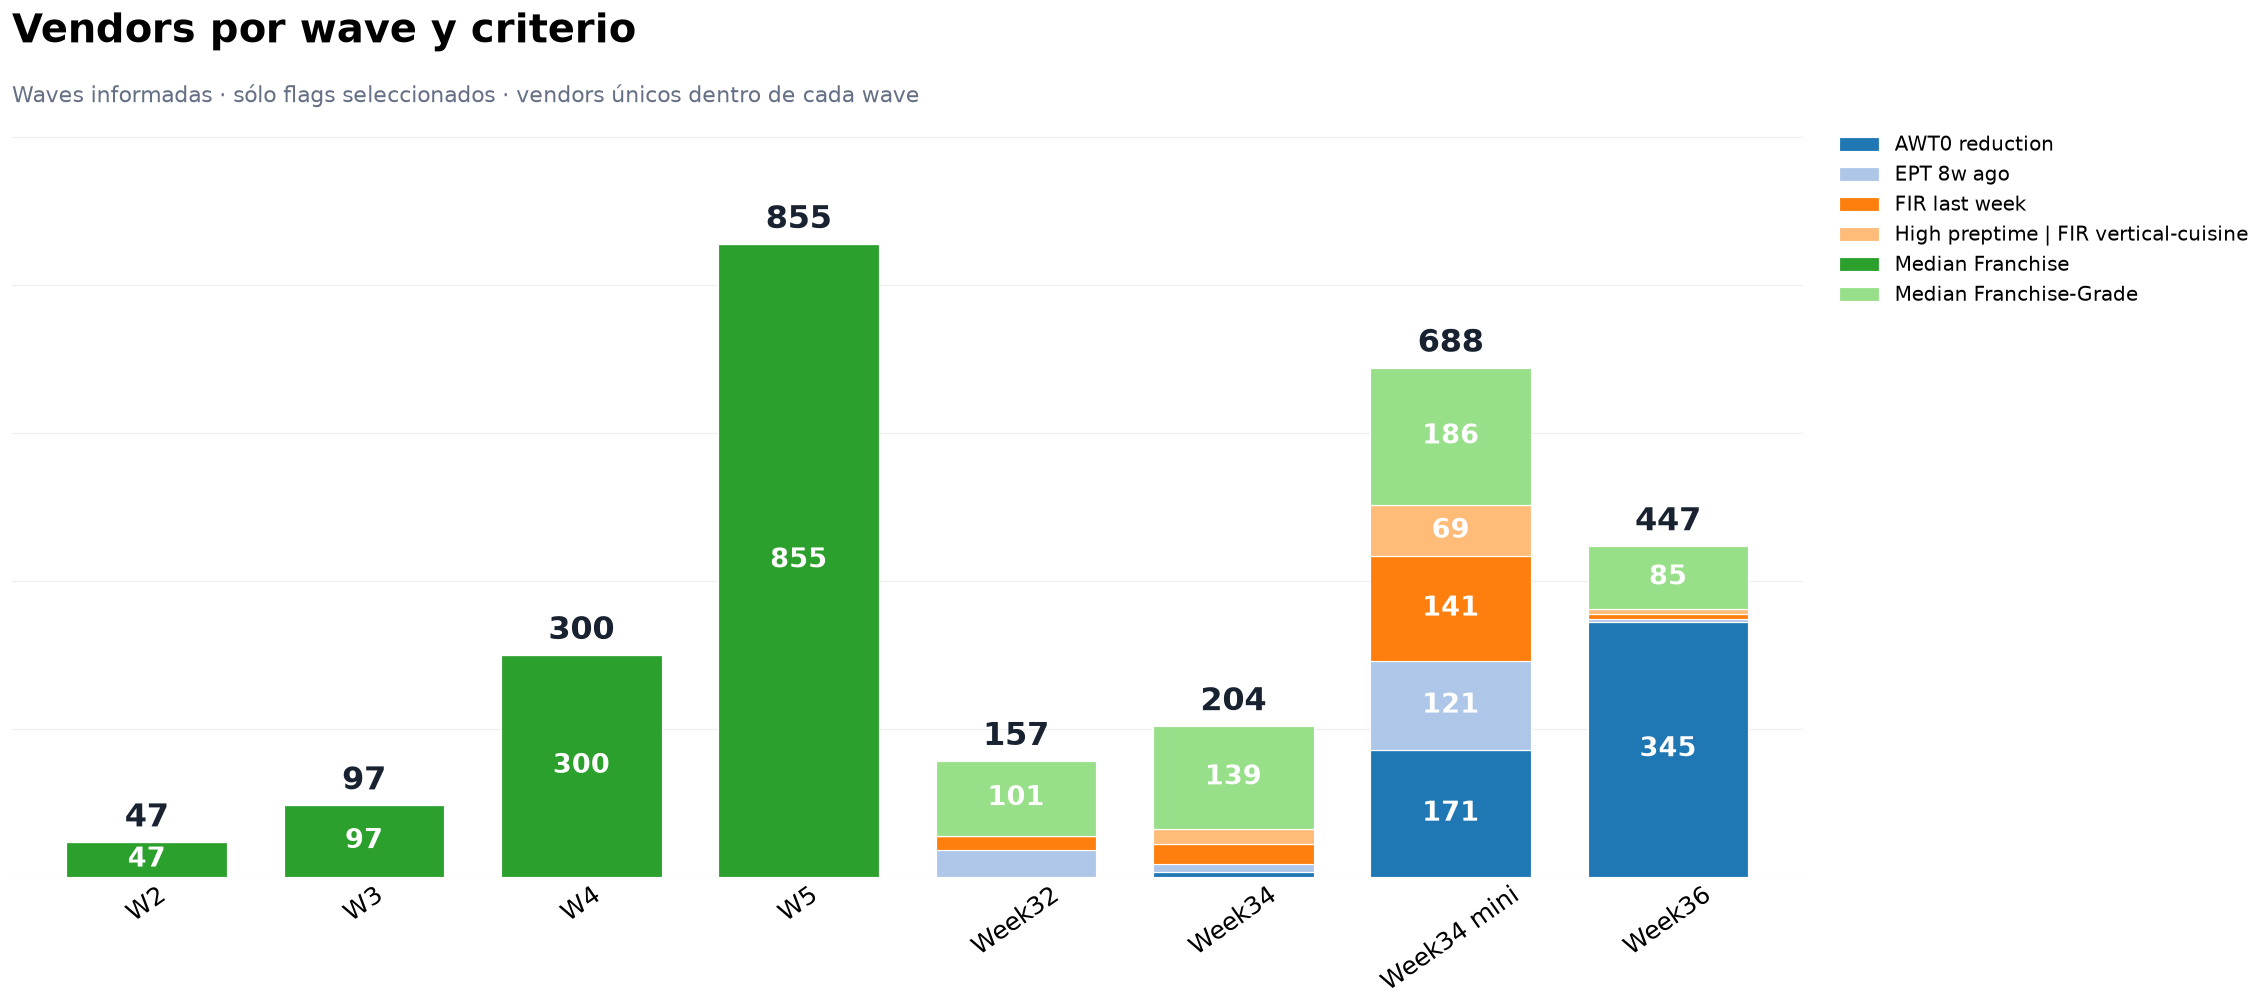

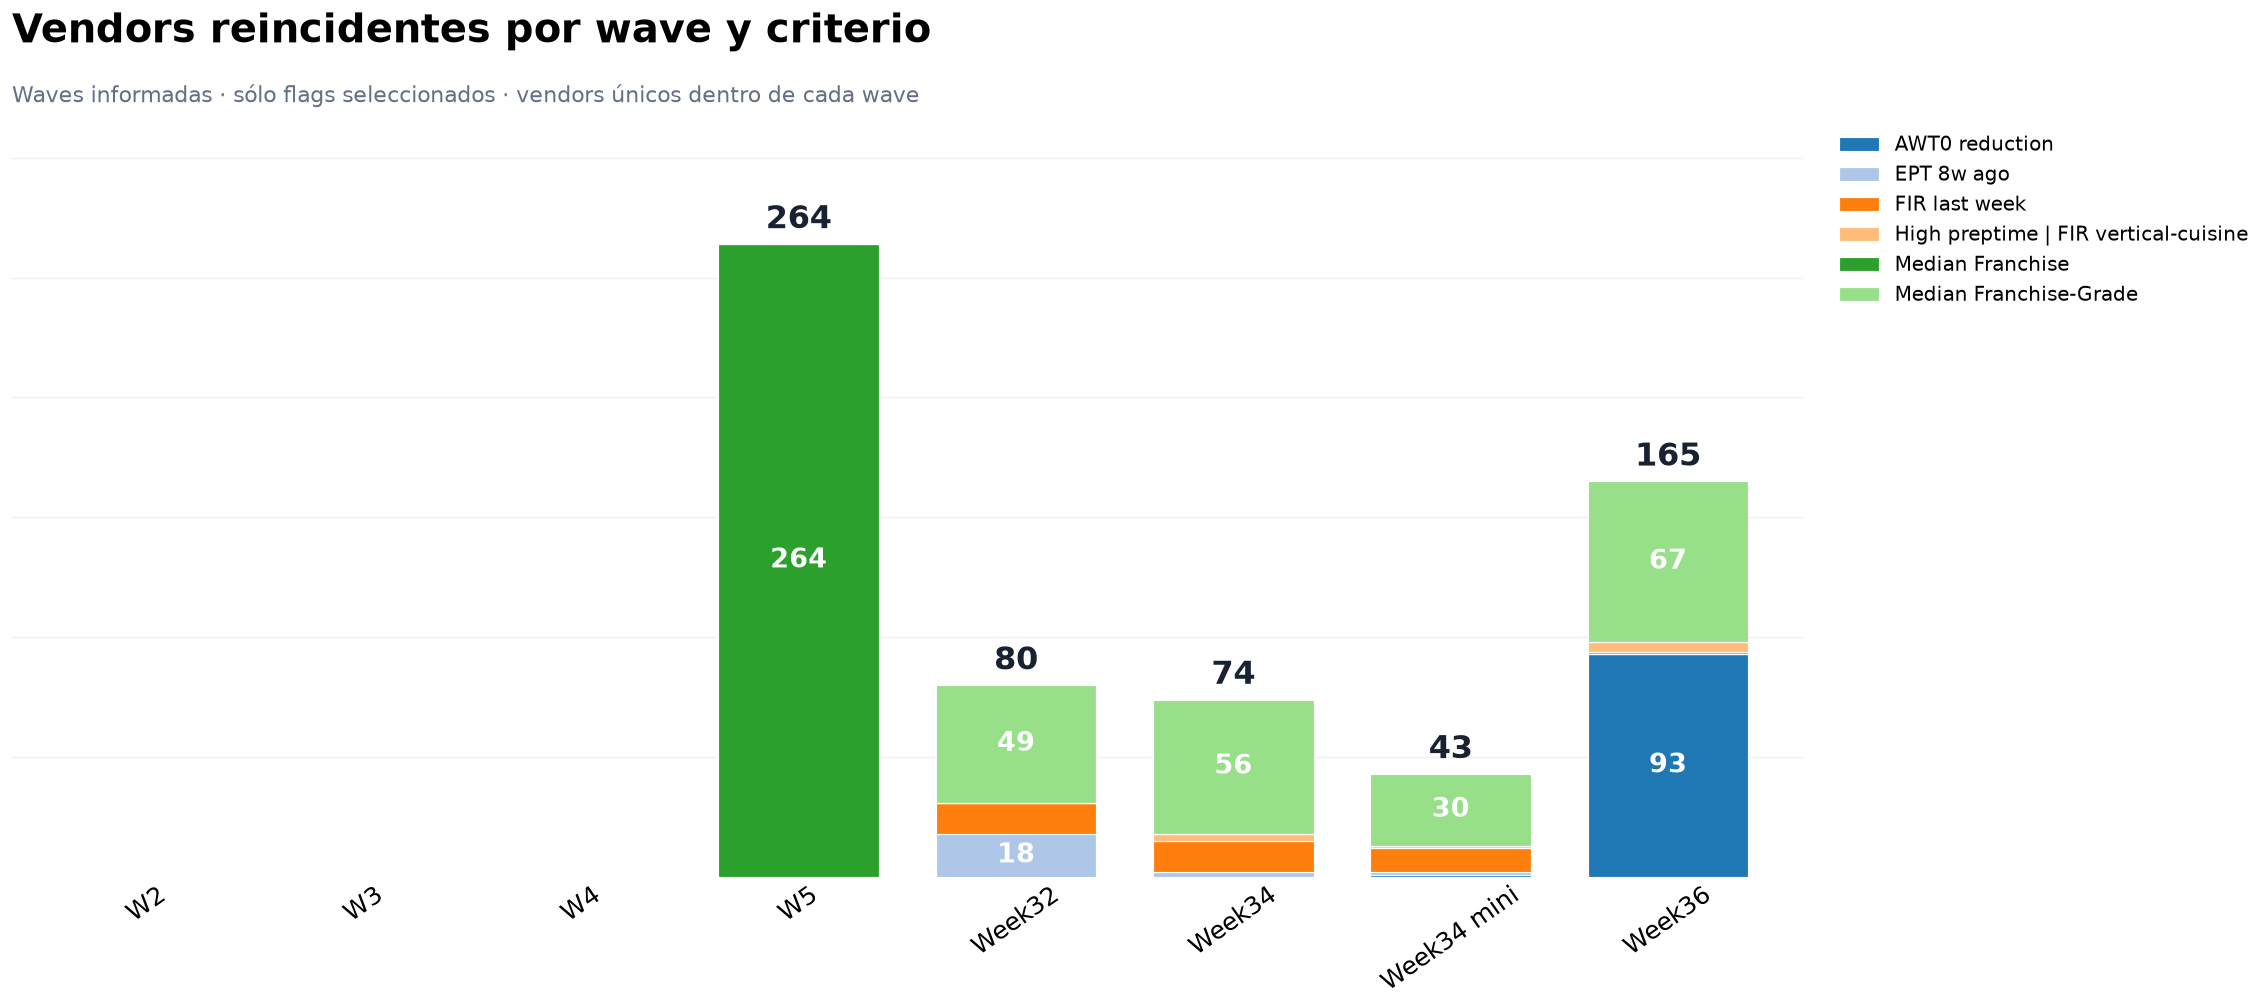

wave,mismo_criterio,nuevo_criterio,total
W2,0,0,0
W3,0,0,0
W4,0,0,0
W5,264,0,264
Week32,0,80,80
Week34,7,67,74
Week34 mini,0,43,43
Week36,31,134,165


vendor_code,waves_con_ajuste,criterios_distintos,cambio_criterio,W2,W3,W4,W5,Week32,Week34,Week34 mini,Week36
101275,2,1,No,—,—,Median Franchise,Median Franchise,—,—,—,—
101277,3,2,Sí,—,—,Median Franchise,Median Franchise,FIR last week,—,—,—
101351,2,1,No,—,—,Median Franchise,Median Franchise,—,—,—,—
101354,3,2,Sí,—,—,Median Franchise,Median Franchise,—,FIR last week,—,—
101909,2,1,No,—,Median Franchise,—,Median Franchise,—,—,—,—
101970,3,2,Sí,—,—,Median Franchise,Median Franchise,Median Franchise-Grade,—,—,—
104663,3,2,Sí,—,—,Median Franchise,Median Franchise,FIR last week,—,—,—
105156,3,2,Sí,Median Franchise,—,—,Median Franchise,—,—,—,AWT0 reduction
106530,2,1,No,—,—,Median Franchise,Median Franchise,—,—,—,—
106538,3,2,Sí,—,—,Median Franchise,Median Franchise,—,—,Median Franchise-Grade,—


vendor_code,store_name,franchise_name,vertical_type,wave,flag,fecha_ajuste,EPT antes del ajuste (min),EPT después del ajuste (min),Cambio EPT registrado (min)
341835,Papa Johns Pizza - Copiapo,Papa John's,Restaurant,W2,Median Franchise,2026-05-20 00:00:00,39.1,21.4,-17.7
535606,Carl's Jr Los Angeles,Carl's Jr.,Restaurant,W2,Median Franchise,2026-05-20 00:00:00,36.8,20.8,-16.0
133509,Papa Johns Pizza - Punta Arenas,Papa John's,Restaurant,W2,Median Franchise,2026-05-20 00:00:00,38.3,22.9,-15.4
422633,Carl's Jr Mall Plaza Tobalaba,Carl's Jr.,Restaurant,W2,Median Franchise,2026-05-20 00:00:00,34.9,19.6,-15.3
316068,Papa Johns Pizza - Iquique Centro,Papa John's,Restaurant,W2,Median Franchise,2026-05-20 00:00:00,37.2,22.3,-14.9
291016,Papa John´s - Coronel,Papa John's,Restaurant,W2,Median Franchise,2026-05-20 00:00:00,36.0,21.8,-14.2
283634,Papa Johns Pizza - Peñaflor,Papa John's,Restaurant,W2,Median Franchise,2026-05-20 00:00:00,36.6,22.5,-14.1
403569,Carl's Jr. Plaza Norte,Carl's Jr.,Restaurant,W2,Median Franchise,2026-05-20 00:00:00,34.1,20.0,-14.1
396858,Papa John's Pizza - Concepción Collao,Papa John's,Restaurant,W2,Median Franchise,2026-05-20 00:00:00,35.4,21.4,-14.0
488323,Papa Johns Pizza - Padre Hurtado,Papa John's,Restaurant,W2,Median Franchise,2026-05-20 00:00:00,33.9,20.0,-13.9


In [12]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def history_text(series):
    text = series.astype('string').str.strip()
    return text.mask(text.str.lower().isin(['', 'null', 'none', 'nan', '<na>', 'nat', 'sin_flag']))


def history_vendor(series):
    return history_text(series).str.replace(r'\\.0$', '', regex=True)


def history_number(series):
    return pd.to_numeric(series.astype('string').str.strip().str.replace(',', '.', regex=False), errors='coerce')


def history_natural_key(value):
    return tuple((0, int(x)) if x.isdigit() else (1, x.lower())
                 for x in re.split(r'(\\d+)', str(value)))


def presentation_table(frame, caption, formats=None):
    # Reverted to display a regular DataFrame style, removing custom CSS properties.
    return (frame.style.format(formats or {}, na_rep='—').hide(axis='index')
            .set_caption(caption))


INCLUDED_FLAGS = [
    'AWT0 reduction',
    'Median Franchise-Grade',
    'FIR last week',
    'EPT 8w ago',
    'High preptime | FIR vertical-cuisine',
    'Median Franchise',
]


required_history = {'wave', 'flag', 'vendor_code'}
if not required_history.issubset(reduction_raw.columns):
    raise KeyError(f'Faltan columnas en reduction_raw: {sorted(required_history - set(reduction_raw.columns))}')

reductions_history_valid = reduction_raw.copy()
for column in ['wave', 'flag']:
    reductions_history_valid[column] = history_text(reductions_history_valid[column])
reductions_history_valid = reductions_history_valid.dropna(subset=['wave', 'flag']).copy()
reductions_history_valid = reductions_history_valid.loc[
    reductions_history_valid['flag'].isin(INCLUDED_FLAGS)
].copy()
reductions_history_valid['vendor_code'] = history_vendor(reductions_history_valid['vendor_code'])
invalid_vendor_rows = int(reductions_history_valid['vendor_code'].isna().sum())
if invalid_vendor_rows:
    print(f'{invalid_vendor_rows:,} registros con wave/flag informados carecen de vendor_code; no se pueden contar como vendors.')
reductions_history_valid = reductions_history_valid.dropna(subset=['vendor_code']).copy()

reductions_history_valid['_event_date'] = pd.NaT
for column in ['executed_at', 'start_date', 'created_at']:
    if column in reductions_history_valid:
        reductions_history_valid['_event_date'] = reductions_history_valid['_event_date'].fillna(
            pd.to_datetime(reductions_history_valid[column], format='mixed', errors='coerce'))
reductions_history_valid['_source_row'] = np.arange(len(reductions_history_valid))
for column in ['ept_old', 'ept_new', 'ept_change_min']:
    if column not in reductions_history_valid:
        reductions_history_valid[column] = np.nan
    reductions_history_valid[column] = history_number(reductions_history_valid[column])

wave_dates_history = reductions_history_valid.groupby('wave')['_event_date'].min()
wave_order_history = sorted(wave_dates_history.index, key=lambda w: (
    pd.isna(wave_dates_history[w]),
    wave_dates_history[w] if pd.notna(wave_dates_history[w]) else pd.Timestamp.max,
    history_natural_key(w)))
wave_position_history = {wave: i for i, wave in enumerate(wave_order_history)}

events_sorted = reductions_history_valid.sort_values(['_event_date', '_source_row'], na_position='last', kind='stable')
vendor_wave_history = (events_sorted.groupby(['vendor_code', 'wave'], as_index=False).agg(
    criterio=('flag', lambda s: ' | '.join(sorted(set(s)))),
    fecha_ajuste=('_event_date', 'min'),
    ept_antes_registro=('ept_old', lambda s: s.iloc[0]),
    ept_despues_registro=('ept_new', lambda s: s.iloc[-1]),
    registros_en_wave=('flag', 'size')))
vendor_wave_history['_wave_position'] = vendor_wave_history['wave'].map(wave_position_history)
vendor_wave_history = vendor_wave_history.sort_values(['vendor_code', '_wave_position']).reset_index(drop=True)
vendor_wave_history['numero_aparicion'] = vendor_wave_history.groupby('vendor_code').cumcount() + 1
vendor_wave_history['criterio_anterior'] = vendor_wave_history.groupby('vendor_code')['criterio'].shift()
vendor_wave_history['es_reincidente_en_wave'] = vendor_wave_history['numero_aparicion'].gt(1)
vendor_wave_history['mismo_criterio'] = (vendor_wave_history['es_reincidente_en_wave'] &
    vendor_wave_history['criterio'].eq(vendor_wave_history['criterio_anterior']))
vendor_wave_history['nuevo_criterio'] = (vendor_wave_history['es_reincidente_en_wave'] &
    ~vendor_wave_history['mismo_criterio'])
reincidencias_wave = vendor_wave_history.loc[vendor_wave_history['es_reincidente_en_wave']].copy()
recurrent_vendor_ids = pd.Index(reincidencias_wave['vendor_code'].unique(), name='vendor_code')

def history_summary(frame):
    return frame.groupby(['wave', 'criterio'], as_index=False).agg(vendors=('vendor_code', 'nunique'))

vendors_por_wave_criterio = history_summary(vendor_wave_history)
reincidentes_por_wave_criterio = history_summary(reincidencias_wave)
criteria_history = sorted(vendor_wave_history['criterio'].unique())
colors_history = {c: plt.get_cmap('tab20')(i % 20) for i, c in enumerate(criteria_history)}

def plot_history_stack(summary, title):
    if summary.empty:
        print(f'{title}: sin registros.')
        return
    wide = (summary.pivot(index='wave', columns='criterio', values='vendors')
            .reindex(index=wave_order_history, columns=criteria_history).fillna(0))
    # Dividir por páginas evita reducir texto cuando hay muchas waves.
    for offset in range(0, len(wide), 14):
        data = wide.iloc[offset:offset + 14]
        fig, ax = plt.subplots(figsize=(19, 8.5), dpi=120)
        data.plot.bar(stacked=True, width=.74, color=[colors_history[c] for c in data],
                      edgecolor='white', linewidth=.7, ax=ax)
        maximum = max(float(data.sum(axis=1).max()), 1)
        for container in ax.containers:
            # Segmentos pequeños quedan legibles en la tabla exacta.
            ax.bar_label(container, labels=[f'{int(v):,}' if v >= .05 * maximum else ''
                         for v in container.datavalues], label_type='center', fontsize=16,
                         color='white', fontweight='bold')
        for x, value in enumerate(data.sum(axis=1)):
            if value:
                ax.text(x, value + .025 * maximum, f'{int(value):,}', ha='center',
                        fontsize=19, fontweight='bold', color='#182230')
        ax.set_title(title, loc='left', fontsize=24, fontweight='bold', pad=45)
        ax.text(0, 1.02, 'Waves informadas · sólo flags seleccionados · vendors únicos dentro de cada wave',
                transform=ax.transAxes, fontsize=13, color='#667085')
        ax.set(xlabel='', ylabel='', ylim=(0, maximum * 1.2))
        ax.tick_params(axis='x', labelsize=15, rotation=35, length=0)
        ax.tick_params(axis='y', labelleft=False, length=0)
        ax.grid(axis='y', alpha=.18)
        ax.set_axisbelow(True)
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False, fontsize=12)
        fig.tight_layout()
        plt.show()


print(f'{len(wave_order_history)} waves con wave informado y flags seleccionados. Sin filtro por nombre, fecha o volumen de órdenes.')
print(f'Flags incluidos: {INCLUDED_FLAGS}')
print('Si un vendor tiene varios flags seleccionados en una misma wave, se muestran juntos para contarlo una sola vez.')
plot_history_stack(vendors_por_wave_criterio, 'Vendors por wave y criterio')
plot_history_stack(reincidentes_por_wave_criterio, 'Vendors reincidentes por wave y criterio')

tabla_reincidencia_por_wave = (vendor_wave_history.groupby('wave').agg(
    mismo_criterio=('mismo_criterio', 'sum'), nuevo_criterio=('nuevo_criterio', 'sum'),
    total=('es_reincidente_en_wave', 'sum')).reindex(wave_order_history).fillna(0).astype(int).reset_index())
display(presentation_table(tabla_reincidencia_por_wave, 'Reincidencias: criterio comparado con la aparición anterior'))

historia_reincidentes_long = vendor_wave_history.loc[
    vendor_wave_history['vendor_code'].isin(recurrent_vendor_ids)].copy()
resumen_reincidente = historia_reincidentes_long.groupby('vendor_code').agg(
    waves_con_ajuste=('wave', 'nunique'), criterios_distintos=('criterio', 'nunique'))
resumen_reincidente['cambio_criterio'] = np.where(resumen_reincidente['criterios_distintos'].gt(1), 'Sí', 'No')
trayectoria = historia_reincidentes_long.pivot(index='vendor_code', columns='wave', values='criterio').reindex(columns=wave_order_history)
tabla_historia_reincidentes = resumen_reincidente.join(trayectoria).reset_index()
display(presentation_table(tabla_historia_reincidentes, 'Trayectoria completa de los vendors reincidentes'))

# El registro de ajustes permite ver directamente el EPT de cada intervención.
# AWT y seamless medidos se incorporan después de la consulta semanal.
tabla_eventos_reincidentes = events_sorted.loc[events_sorted['vendor_code'].isin(recurrent_vendor_ids),
    [c for c in ['vendor_code', 'store_name', 'franchise_name', 'vertical_type', 'wave', 'flag',
                 '_event_date', 'ept_old', 'ept_new', 'ept_change_min'] if c in events_sorted]].copy()
tabla_eventos_reincidentes = tabla_eventos_reincidentes.rename(columns={
    '_event_date': 'fecha_ajuste', 'ept_old': 'EPT antes del ajuste (min)',
    'ept_new': 'EPT después del ajuste (min)', 'ept_change_min': 'Cambio EPT registrado (min)'})
display(presentation_table(tabla_eventos_reincidentes, 'Reincidentes: EPT registrado en cada ajuste',
    {c: '{:.1f}' for c in tabla_eventos_reincidentes if '(min)' in c}))

### AWT0 / AWTnull — última semana cerrada

Una consulta a nivel vendor para lunes–domingo, sin conversión horaria, entrega
orders, `awt0_share`, `awtnull_share`, EPT promedio, AWT promedio y seamless.
Todos los buckets exigen **al menos 25 orders en esa semana**. El historial por
flag y la lista de reincidentes conservan todos los vendors con wave/flag informados.

El denominador **% orders CL** incluye todas las órdenes elegibles del país antes
del filtro de 25; por eso los buckets pueden sumar menos de 100%. Las métricas se
recalculan sumando numeradores y denominadores. Seamless usa órdenes clasificadas y
muestra su cobertura; EPT usa órdenes con EPT válido.

La cobertura histórica incluye W1, W2, Week, Mini y cualquier otro nombre con flag
informado. Es pertenencia al historial, no una atribución causal ni evidencia de
que el ajuste estuviera activo durante la semana consultada. La vista consolidada
cuenta una vez cada vendor. Las tablas por wave conservan sus apariciones.


In [13]:
# AWT0 / AWTnull, seamless y EPT — última semana cerrada, lunes a domingo.
# Consulta única para todas las tablas de buckets; sin conversión horaria.
import numpy as np
import pandas as pd
from google.cloud import bigquery
from IPython.display import display

MIN_ORDERS_LAST_WEEK = 25

awt_last_closed_week_query = r"""
WITH params AS (
  SELECT
    DATE_SUB(DATE_TRUNC(CURRENT_DATE(), WEEK(MONDAY)), INTERVAL 7 DAY) AS week_start,
    DATE_SUB(DATE_TRUNC(CURRENT_DATE(), WEEK(MONDAY)), INTERVAL 1 DAY) AS week_end
),
partners AS (
  -- Una fila por partner para no multiplicar órdenes al incorporar metadatos.
  SELECT
    CAST(partner_id AS STRING) AS vendor_code,
    ANY_VALUE(partner_name) AS store_name,
    ANY_VALUE(CAST(franchise.franchise_id AS STRING)) AS franchise_id,
    ANY_VALUE(franchise.franchise_name) AS franchise_name
  FROM `peya-bi-tools-pro.il_core.dim_partner`
  WHERE is_online = TRUE
  GROUP BY vendor_code
),
base AS (
  SELECT
    CAST(l.peya_order_id AS STRING) AS order_id,
    CAST(l.vendor.vendor_code AS STRING) AS vendor_code,
    ANY_VALUE(p.store_name) AS store_name,
    ANY_VALUE(p.franchise_id) AS franchise_id,
    ANY_VALUE(p.franchise_name) AS franchise_name,
    ANY_VALUE(l.vendor.vertical_type) AS vertical_type,
    MAX(SAFE_DIVIDE(l.estimated_prep_time, 60.0)) AS ept_min,
    MAX(SAFE_DIVIDE(l.timings.avoidable_wait_time, 60.0)) AS awt_min
  FROM `peya-bi-tools-pro.il_logistics.fact_logistic_orders` l
  INNER JOIN partners p ON CAST(l.vendor.vendor_code AS STRING) = p.vendor_code
  CROSS JOIN params
  WHERE l.country_code = 'cl'
    AND l.peya_order_id IS NOT NULL
    AND EXISTS (SELECT 1 FROM UNNEST(l.deliveries) d WHERE d.is_primary = TRUE)
    AND l.is_preorder = FALSE
    AND COALESCE(l.vendor.vertical_type, '') != 'courier_business'
    AND DATE(l.created_date_local) BETWEEN params.week_start AND params.week_end
  GROUP BY order_id, vendor_code
),
seamless_by_order AS (
  -- Si hay etiquetas contradictorias para una orden, queda sin clasificar.
  -- Esto evita sumar varias veces la misma orden o asumir seamless al faltar data.
  SELECT
    CAST(n.order_id AS STRING) AS order_id,
    IF(COUNT(DISTINCT SAFE_CAST(n.SEAMLESS AS INT64)) = 1,
       MAX(SAFE_CAST(n.SEAMLESS AS INT64)), NULL) AS seamless
  FROM `peya-delivery-and-support.automated_tables_reports.non_seamless_reasons` n
  CROSS JOIN params
  WHERE n.country_name = 'Chile'
    AND n.created_date_local BETWEEN params.week_start AND params.week_end
  GROUP BY order_id
),
vendor_metrics AS (
  SELECT
    b.vendor_code,
    ANY_VALUE(b.store_name) AS store_name,
    ANY_VALUE(b.franchise_id) AS franchise_id,
    ANY_VALUE(b.franchise_name) AS franchise_name,
    ANY_VALUE(b.vertical_type) AS vertical_type,
    COUNT(*) AS total_orders,
    COUNTIF(b.awt_min = 0) AS awt0_orders,
    COUNTIF(b.awt_min IS NULL) AS awt_null_orders,
    SUM(b.ept_min) AS ept_sum,
    COUNT(b.ept_min) AS ept_orders,
    SUM(b.awt_min) AS awt_sum,
    COUNT(b.awt_min) AS awt_orders,
    COUNTIF(s.seamless = 1) AS seamless_orders,
    COUNTIF(s.seamless IN (0, 1)) AS seamless_classified_orders
  FROM base b
  LEFT JOIN seamless_by_order s USING (order_id)
  GROUP BY b.vendor_code
),
cl_total AS (
  -- Total nacional ANTES del filtro >=25 orders por vendor.
  SELECT SUM(total_orders) AS total_orders_cl, COUNT(*) AS total_vendors_cl
  FROM vendor_metrics
)
SELECT
  p.week_start, p.week_end, v.*, c.total_orders_cl, c.total_vendors_cl,
  v.total_orders AS orders_last_week,
  SAFE_DIVIDE(v.total_orders, c.total_orders_cl) AS orders_share_cl,
  SAFE_DIVIDE(v.awt0_orders, v.total_orders) AS awt0_share,
  SAFE_DIVIDE(v.awt_null_orders, v.total_orders) AS awtnull_share,
  SAFE_DIVIDE(v.ept_sum, v.ept_orders) AS ept_avg,
  SAFE_DIVIDE(v.awt_sum, v.awt_orders) AS awt_avg,
  SAFE_DIVIDE(v.seamless_orders, v.seamless_classified_orders) AS seamless_share,
  SAFE_DIVIDE(v.seamless_classified_orders, v.total_orders) AS seamless_coverage
FROM vendor_metrics v
CROSS JOIN cl_total c
CROSS JOIN params p
ORDER BY v.total_orders DESC
"""

project_id = PROJECT_ID
bq_client = bigquery.Client(project=project_id)
vendor_awt_last_week_all = bq_client.query(awt_last_closed_week_query).to_dataframe()
if vendor_awt_last_week_all.empty:
    raise ValueError('La consulta semanal no devolvió órdenes CL.')
vendor_awt_last_week_all['vendor_code'] = history_vendor(vendor_awt_last_week_all['vendor_code'])
if vendor_awt_last_week_all['vendor_code'].duplicated().any():
    raise ValueError('La consulta debe entregar una sola fila por vendor.')
numeric_weekly = [
    'total_orders', 'orders_last_week', 'awt0_orders', 'awt_null_orders',
    'ept_sum', 'ept_orders', 'awt_sum', 'awt_orders', 'seamless_orders', 'seamless_classified_orders',
    'total_orders_cl', 'total_vendors_cl', 'orders_share_cl', 'awt0_share', 'awtnull_share',
    'ept_avg', 'awt_avg', 'seamless_share', 'seamless_coverage']
for column in numeric_weekly:
    vendor_awt_last_week_all[column] = pd.to_numeric(vendor_awt_last_week_all[column], errors='coerce')

week_start_awt = pd.to_datetime(vendor_awt_last_week_all['week_start'].iloc[0]).date()
week_end_awt = pd.to_datetime(vendor_awt_last_week_all['week_end'].iloc[0]).date()
total_orders_cl_awt = float(vendor_awt_last_week_all['total_orders_cl'].iloc[0])
total_vendors_cl_awt = int(vendor_awt_last_week_all['total_vendors_cl'].iloc[0])
if (vendor_awt_last_week_all['total_orders_cl'].nunique() != 1 or
    not np.isclose(vendor_awt_last_week_all['total_orders'].sum(), total_orders_cl_awt)):
    raise ValueError('El total nacional no reconcilia con las órdenes por vendor.')

# Waves con nombre informado y flags seleccionados; un vendor puede figurar en varias.
ids_all_waves = set(vendor_wave_history['vendor_code'])
ids_any_awt0 = set(reductions_history_valid.loc[
    reductions_history_valid['flag'].str.lower().str.replace(r'[\s_]+', '', regex=True)
    .str.contains('awt0', na=False), 'vendor_code'])
# Se mantiene una vista de la última wave como complemento al total histórico.
latest_dated = [w for w in wave_order_history if pd.notna(wave_dates_history[w])]
latest_week_wave = latest_dated[-1] if latest_dated else (wave_order_history[-1] if wave_order_history else None)
latest_wave_vendors = set(vendor_wave_history.loc[
    vendor_wave_history['wave'].eq(latest_week_wave), 'vendor_code'])
for column, ids in [('is_any_wave', ids_all_waves), ('is_awt0_reduction', ids_any_awt0),
                    ('is_latest_week_wave', latest_wave_vendors)]:
    vendor_awt_last_week_all[column] = vendor_awt_last_week_all['vendor_code'].isin(ids)

vendor_awt_last_week = vendor_awt_last_week_all.loc[
    vendor_awt_last_week_all['orders_last_week'].ge(MIN_ORDERS_LAST_WEEK)].copy()
eligible_orders_pct = 100 * vendor_awt_last_week['total_orders'].sum() / total_orders_cl_awt
print(f'Semana: {week_start_awt:%d/%m/%Y}–{week_end_awt:%d/%m/%Y}')
print(f'CL completo: {total_vendors_cl_awt:,} vendors · {total_orders_cl_awt:,.0f} órdenes.')
print(f'Buckets: {len(vendor_awt_last_week):,} vendors con >= {MIN_ORDERS_LAST_WEEK} órdenes · '
      f'{eligible_orders_pct:.2f}% de todas las órdenes CL.')
print('EPT = suma de minutos / órdenes con EPT. Seamless = seamless / órdenes clasificadas; '
      'se muestra también la cobertura de clasificación.')
print('La pertenencia a waves es histórica: aparecer en una wave no significa que el ajuste '
      'ya estuviera aplicado durante esta semana.')

# LISTA DE REINCIDENTES: EPT REGISTRADO + MÉTRICAS DE LA SEMANA CONSULTADA.
# No se aplica el umbral de 25 a esta lista: se conserva cada reincidente.
last_history = historia_reincidentes_long.sort_values(['vendor_code', '_wave_position'])
recurrence_log = last_history.groupby('vendor_code', as_index=False).agg(
    primera_wave=('wave', 'first'), ultima_wave=('wave', 'last'),
    ept_primer_ajuste_antes=('ept_antes_registro', lambda s: s.iloc[0]),
    ept_ultimo_ajuste_antes=('ept_antes_registro', lambda s: s.iloc[-1]),
    ept_ultimo_ajuste_despues=('ept_despues_registro', lambda s: s.iloc[-1]))
meta_cols = [c for c in ['store_name', 'franchise_name', 'vertical_type'] if c in events_sorted]
log_meta = events_sorted.drop_duplicates('vendor_code', keep='last')[['vendor_code'] + meta_cols]
tabla_stats_reincidentes = (resumen_reincidente.reset_index().merge(recurrence_log, on='vendor_code', how='left', validate='one_to_one')
    .merge(vendor_awt_last_week_all, on='vendor_code', how='left', validate='one_to_one')
    .merge(log_meta, on='vendor_code', how='left', suffixes=('', '_registro'), validate='one_to_one'))
for column in meta_cols:
    tabla_stats_reincidentes[column] = tabla_stats_reincidentes[column].fillna(tabla_stats_reincidentes[column + '_registro'])
tabla_stats_reincidentes['stats_desde'] = week_start_awt
tabla_stats_reincidentes['stats_hasta'] = week_end_awt
tabla_stats_reincidentes['estado_stats'] = np.where(tabla_stats_reincidentes['total_orders'].notna(),
    'Medido en la semana consultada', 'Sin órdenes en el universo consultado')
tabla_stats_reincidentes['incluido_en_buckets'] = tabla_stats_reincidentes['orders_last_week'].ge(MIN_ORDERS_LAST_WEEK)
for column in ['orders_share_cl', 'awt0_share', 'awtnull_share', 'seamless_share', 'seamless_coverage']:
    tabla_stats_reincidentes[column + '_pct'] = 100 * tabla_stats_reincidentes[column]
recurrence_columns = ['vendor_code', 'store_name', 'franchise_name', 'vertical_type', 'waves_con_ajuste',
    'primera_wave', 'ultima_wave', 'ept_primer_ajuste_antes', 'ept_ultimo_ajuste_antes', 'ept_ultimo_ajuste_despues',
    'stats_desde', 'stats_hasta', 'orders_last_week', 'orders_share_cl_pct', 'ept_avg', 'awt_avg',
    'awt0_share_pct', 'awtnull_share_pct', 'seamless_share_pct', 'seamless_coverage_pct',
    'incluido_en_buckets', 'estado_stats']
tabla_stats_reincidentes = tabla_stats_reincidentes[recurrence_columns].sort_values(
    ['waves_con_ajuste', 'orders_last_week'], ascending=False)
recurrence_formats = {c: '{:.2f}%' for c in recurrence_columns if c.endswith('_pct')}
recurrence_formats.update({c: '{:.2f}' for c in recurrence_columns if c.startswith('ept_') or c == 'awt_avg'})
recurrence_formats['orders_last_week'] = '{:,.0f}'
print('\nEPT de cada ajuste: tabla_eventos_reincidentes. AWT0, AWTnull, EPT promedio y seamless '
      'de esta lista corresponden únicamente a la semana stats_desde–stats_hasta.')
display(presentation_table(tabla_stats_reincidentes, 'Reincidentes: ajustes registrados y estadísticas semanales', recurrence_formats))


c:\Users\pablo.villanueva\.gemini\antigravity\scratch\bigquery_pipeline\github primer repo\lower-ept-y-awt\.venv\Lib\site-packages\google\auth\_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
c:\Users\pablo.villanueva\.gemini\antigravity\scratch\bigquery_pipeline\github primer repo\lower-ept-y-awt\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Semana: 31/08/2026–06/09/2026
CL completo: 14,905 vendors · 825,334 órdenes.
Buckets: 5,693 vendors con >= 25 órdenes · 90.66% de todas las órdenes CL.
EPT = suma de minutos / órdenes con EPT. Seamless = seamless / órdenes clasificadas; se muestra también la cobertura de clasificación.
La pertenencia a waves es histórica: aparecer en una wave no significa que el ajuste ya estuviera aplicado durante esta semana.

EPT de cada ajuste: tabla_eventos_reincidentes. AWT0, AWTnull, EPT promedio y seamless de esta lista corresponden únicamente a la semana stats_desde–stats_hasta.


vendor_code,store_name,franchise_name,vertical_type,waves_con_ajuste,primera_wave,ultima_wave,ept_primer_ajuste_antes,ept_ultimo_ajuste_antes,ept_ultimo_ajuste_despues,stats_desde,stats_hasta,orders_last_week,orders_share_cl_pct,ept_avg,awt_avg,awt0_share_pct,awtnull_share_pct,seamless_share_pct,seamless_coverage_pct,incluido_en_buckets,estado_stats
133752,Papa John's - Coquimbo,Papa John's,restaurants,4,W2,Week36,32.80,22.80,14.90,2026-08-31,2026-09-06,589,0.07%,20.47,3.51,33.28%,3.40%,87.78%,100.00%,True,Medido en la semana consultada
205374,Little Caesars Pizza Alameda,Little Caesar's,restaurants,4,W3,Week34,31.10,18.90,8.80,2026-08-31,2026-09-06,472,0.06%,12.52,4.78,17.80%,15.47%,79.66%,100.00%,True,Medido en la semana consultada
121683,Burger King® - Los Andes,Burger King,restaurants,4,W3,Week36,24.70,20.50,12.20,2026-08-31,2026-09-06,444,0.05%,19.45,8.00,11.26%,10.59%,62.39%,100.00%,True,Medido en la semana consultada
360153,Under Pizza - República,Under Pizzas,restaurants,4,W4,Week36,34.50,27.60,18.60,2026-08-31,2026-09-06,353,0.04%,25.26,6.20,13.88%,11.90%,72.24%,100.00%,True,Medido en la semana consultada
282865,Papa Johns Pizza - Alto Hospicio,Papa John's,restaurants,4,W2,Week34,30.40,27.00,15.70,2026-08-31,2026-09-06,326,0.04%,24.67,7.18,11.35%,13.19%,67.79%,100.00%,True,Medido en la semana consultada
488323,Papa Johns Pizza - Padre Hurtado,Papa John's,restaurants,4,W2,Week36,33.90,31.50,19.30,2026-08-31,2026-09-06,269,0.03%,25.67,7.46,18.22%,14.13%,73.61%,100.00%,True,Medido en la semana consultada
319541,Papa Johns Pizza - San Antonio,Papa John's,restaurants,4,W2,Week36,30.50,15.30,9.40,2026-08-31,2026-09-06,232,0.03%,15.03,5.59,17.67%,10.34%,86.21%,100.00%,True,Medido en la semana consultada
502040,Little Caesars Pizza - Enea,Little Caesar's,restaurants,4,W3,Week36,32.10,25.50,15.80,2026-08-31,2026-09-06,206,0.02%,14.64,13.46,4.37%,25.73%,63.11%,100.00%,True,Medido en la semana consultada
133585,Papa Johns Pizza - Puerto Montt Ibañez,Papa John's,restaurants,4,W2,Week34,32.10,23.70,13.70,2026-08-31,2026-09-06,187,0.02%,20.51,6.07,8.56%,22.99%,69.52%,100.00%,True,Medido en la semana consultada
491955,Under Pizza - Talcahuano,Under Pizzas,restaurants,4,W4,Week36,38.70,26.50,14.60,2026-08-31,2026-09-06,180,0.02%,14.82,5.38,14.44%,5.56%,93.89%,100.00%,True,Medido en la semana consultada


In [14]:
# UN SOLO GENERADOR DE BUCKETS PARA AWT0 Y AWTnull.
# Esta celda prepara tablas. Los gráficos se muestran al final del notebook.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

AWT_SHARE_EDGES = [i / 10 for i in range(10)] + [1.000000001]
AWT_SHARE_LABELS = [f'[{i}–{i + 10}%)' for i in range(0, 90, 10)] + ['[90–100%]']
AWT_SEGMENTS = ['Fuera de selección', 'Otros criterios', 'Criterio AWT0']
AWT_SEGMENT_COLORS = ['#D0D5DD', '#7355B8', '#2563EB']


def build_awt_bucket_tables(vendor_df, share_col, selected_ids, criterion_awt0_ids, selection_label):
    # El umbral se verifica aquí para que todos los consumidores usen la misma cohorte.
    data = vendor_df.loc[vendor_df['orders_last_week'].ge(MIN_ORDERS_LAST_WEEK)].copy()
    if data['vendor_code'].duplicated().any():
        raise ValueError('Los buckets requieren una sola fila por vendor.')
    if not data[share_col].between(0, 1).all():
        raise ValueError(f'{share_col} debe ser una proporción válida 0–1. No se interpreta NULL como cero.')
    data['bucket'] = pd.cut(data[share_col], bins=AWT_SHARE_EDGES, labels=AWT_SHARE_LABELS, right=False)
    selected = data['vendor_code'].isin(selected_ids)
    by_awt0 = selected & data['vendor_code'].isin(criterion_awt0_ids)
    data['segment'] = np.select([by_awt0, selected], ['Criterio AWT0', 'Otros criterios'], default='Fuera de selección')
    raw_columns = ['total_orders', 'ept_sum', 'ept_orders', 'awt_sum', 'awt_orders', 'awt0_orders',
                   'awt_null_orders', 'seamless_orders', 'seamless_classified_orders']

    def aggregate(frame, keys):
        spec = {'vendors': ('vendor_code', 'nunique')}
        spec.update({column: (column, 'sum') for column in raw_columns})
        result = frame.groupby(keys, observed=False).agg(**spec)
        # Razones siempre calculadas a partir de numeradores y denominadores.
        result['orders_share_cl_pct'] = 100 * result['total_orders'] / total_orders_cl_awt
        result['vendor_share_cl_pct'] = 100 * result['vendors'] / total_vendors_cl_awt
        result['ept_avg'] = result['ept_sum'] / result['ept_orders'].replace(0, np.nan)
        result['awt_avg'] = result['awt_sum'] / result['awt_orders'].replace(0, np.nan)
        result['seamless_pct'] = 100 * result['seamless_orders'] / result['seamless_classified_orders'].replace(0, np.nan)
        result['seamless_coverage_pct'] = 100 * result['seamless_classified_orders'] / result['total_orders'].replace(0, np.nan)
        result['awt0_pct'] = 100 * result['awt0_orders'] / result['total_orders'].replace(0, np.nan)
        result['awtnull_pct'] = 100 * result['awt_null_orders'] / result['total_orders'].replace(0, np.nan)
        return result

    detail = aggregate(data, ['bucket', 'segment']).reset_index()
    summary = aggregate(data, ['bucket']).reindex(AWT_SHARE_LABELS)
    def pivot(column):
        return (detail.pivot(index='bucket', columns='segment', values=column)
                .reindex(index=AWT_SHARE_LABELS, columns=AWT_SEGMENTS).fillna(0))
    vendors, orders, orders_pct = pivot('vendors'), pivot('total_orders'), pivot('orders_share_cl_pct')
    summary['vendors_en_seleccion'] = vendors[AWT_SEGMENTS[1:]].sum(axis=1)
    summary['orders_en_seleccion'] = orders[AWT_SEGMENTS[1:]].sum(axis=1)
    summary['orders_en_seleccion_share_cl_pct'] = orders_pct[AWT_SEGMENTS[1:]].sum(axis=1)
    summary['cobertura_vendors_bucket_pct'] = 100 * summary['vendors_en_seleccion'] / summary['vendors'].replace(0, np.nan)
    summary['cobertura_orders_bucket_pct'] = 100 * summary['orders_en_seleccion'] / summary['total_orders'].replace(0, np.nan)
    if int(summary['vendors'].sum()) != len(data) or not np.isclose(summary['total_orders'].sum(), data['total_orders'].sum()):
        raise ValueError('La distribución no reconcilia con su universo de vendors/órdenes.')
    summary.index.name = 'bucket'
    return {'summary': summary.reset_index(), 'detail': detail, 'vendors': vendors,
            'orders': orders, 'orders_pct': orders_pct, 'vendor_detail': data,
            'selection_label': selection_label, 'share_col': share_col}


def show_awt_bucket_table(result, title):
    columns = ['bucket', 'vendors', 'vendors_en_seleccion', 'cobertura_vendors_bucket_pct',
               'total_orders', 'orders_share_cl_pct', 'orders_en_seleccion',
               'orders_en_seleccion_share_cl_pct', 'cobertura_orders_bucket_pct',
               'seamless_pct', 'seamless_coverage_pct', 'ept_avg', 'awt_avg', 'awt0_pct', 'awtnull_pct']
    names = {'bucket': 'Bucket', 'vendors': 'Vendors ≥25 orders', 'vendors_en_seleccion': 'Vendors seleccionados',
        'cobertura_vendors_bucket_pct': '% vendors del bucket alcanzados', 'total_orders': 'Orders del bucket',
        'orders_share_cl_pct': '% orders CL del bucket', 'orders_en_seleccion': 'Orders seleccionadas',
        'orders_en_seleccion_share_cl_pct': '% orders CL alcanzadas',
        'cobertura_orders_bucket_pct': '% orders del bucket alcanzadas',
        'seamless_pct': 'Seamless (%)', 'seamless_coverage_pct': 'Clasificación seamless (%)',
        'ept_avg': 'EPT promedio (min)', 'awt_avg': 'AWT promedio (min)',
        'awt0_pct': 'AWT0 real (%)', 'awtnull_pct': 'AWTnull real (%)'}
    formats = {names[c]: '{:.2f}%' if c.endswith('_pct') else
               '{:.2f}' if c.endswith('_avg') else '{:,.0f}' for c in columns if c != 'bucket'}
    display(presentation_table(result['summary'][columns].rename(columns=names), title, formats))


def plot_awt_bucket_stack(result, metric_label, mode='vendors'):
    data = result['vendors'] if mode == 'vendors' else result['orders_pct']
    percent = mode != 'vendors'
    unit = '% de órdenes CL' if percent else 'Vendors únicos'
    fmt = (lambda value: f'{value:.2f}%') if percent else (lambda value: f'{int(round(value)):,}')
    total = data.sum(axis=1)
    if total.sum() <= 0:
        print(f'{metric_label} · {result["selection_label"]}: sin vendors con >=25 órdenes.')
        return
    maximum = max(float(total.max()), .01)
    fig, ax = plt.subplots(figsize=(19, 8.5), dpi=140)
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    x = np.arange(len(data))
    bottom = np.zeros(len(data))
    small_labels = {i: [] for i in range(len(data))}
    for segment, color in zip(AWT_SEGMENTS, AWT_SEGMENT_COLORS):
        values = data[segment].to_numpy(dtype=float)
        bars = ax.bar(x, values, bottom=bottom, width=.7, color=color, label=segment,
                      edgecolor='white', linewidth=1)
        for i, bar in enumerate(bars):
            height = bar.get_height()
            if height <= 0:
                continue
            center = bottom[i] + height / 2
            if height >= .065 * maximum:
                ax.text(i, center, fmt(height), ha='center', va='center', fontsize=17,
                        fontweight='bold', color='#344054' if segment == AWT_SEGMENTS[0] else 'white')
            else:
                small_labels[i].append((center, fmt(height), color))
        bottom += values
    # Totales grandes; las cifras de segmentos pequeños se desplazan hacia arriba.
    for i, value in enumerate(total):
        if value > 0:
            ax.annotate(fmt(value), (i, value), xytext=(0, 9), textcoords='offset points',
                        ha='center', fontsize=20, fontweight='bold', color='#182230')
        for j, (center, label, color) in enumerate(small_labels[i]):
            ax.annotate(label, xy=(i + .28, center), xytext=(i, value + maximum * (.13 + .08 * j)),
                        ha='center', va='bottom', fontsize=15, fontweight='bold', color='#344054' if color == '#D0D5DD' else color,
                        arrowprops={'arrowstyle': '-', 'lw': .8, 'color': color,
                                    'connectionstyle': 'angle,angleA=0,angleB=90,rad=3'})
    covered = result['summary']['vendors_en_seleccion'].sum()
    covered_orders_pct = result['summary']['orders_en_seleccion_share_cl_pct'].sum()
    selected_vendors = result['vendor_detail'].loc[result['vendor_detail']['segment'].ne(AWT_SEGMENTS[0])]
    franchises = selected_vendors['franchise_id'].nunique()
    covered_orders = result['summary']['orders_en_seleccion'].sum()
    metadata = (f'{week_start_awt:%d/%m/%Y}–{week_end_awt:%d/%m/%Y} · ≥{MIN_ORDERS_LAST_WEEK} orders por vendor\n'
                f'Selección: {covered:,.0f} vendors · {franchises:,} franquicias · '
                f'{covered_orders:,.0f} órdenes ({covered_orders_pct:.2f}% CL)\n'
                f'CL: {total_vendors_cl_awt:,} vendors · {total_orders_cl_awt:,.0f} órdenes · '
                f'Cobertura del filtro: {result["summary"]["orders_share_cl_pct"].sum():.2f}% orders CL')
    fig.text(.055, .950, f'{metric_label} · {unit}', fontsize=24, fontweight='bold', color='#182230')
    fig.text(.055, .902, result['selection_label'], fontsize=17, fontweight='semibold', color='#344054')
    fig.text(.055, .809, metadata, fontsize=13, linespacing=1.5, color='#667085')
    ax.set_xticks(x)
    ax.set_xticklabels(AWT_SHARE_LABELS, fontsize=16, rotation=30, ha='right')
    # Conservar los buckets en X y la rejilla; quitar cifras y títulos redundantes de ejes.
    ax.set(xlabel='', ylabel='', ylim=(0, maximum * 1.48))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.tick_params(axis='y', left=False, labelleft=False)
    ax.tick_params(axis='x', length=0, colors='#344054')
    ax.grid(axis='y', color='#E4E7EC', alpha=.8, linewidth=.8)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.legend(loc='upper center', bbox_to_anchor=(.5, 1.07), ncol=3, frameon=False, fontsize=14)
    fig.subplots_adjust(top=.71, bottom=.19, left=.055, right=.985)
    plt.show()


awt_bucket_results = {}
awt_bucket_results_by_wave = {}
metrics_for_shares = [('AWT0', 'awt0_share'), ('AWTnull', 'awtnull_share')]
for metric_label, share_col in metrics_for_shares:
    awt_bucket_results[(metric_label, 'todas')] = build_awt_bucket_tables(
        vendor_awt_last_week, share_col, ids_all_waves, ids_any_awt0,
        'Al menos una wave con flag seleccionado')
    for wave in wave_order_history:
        rows = reductions_history_valid.loc[reductions_history_valid['wave'].eq(wave)]
        wave_ids = set(rows['vendor_code'])
        criterion_ids = set(rows.loc[rows['flag'].str.lower().str.replace(r'[\s_]+', '', regex=True)
                           .str.contains('awt0', na=False), 'vendor_code'])
        awt_bucket_results_by_wave[(metric_label, wave)] = build_awt_bucket_tables(
            vendor_awt_last_week, share_col, wave_ids, criterion_ids, str(wave))
    if latest_week_wave is not None:
        awt_bucket_results[(metric_label, 'ultima')] = awt_bucket_results_by_wave[(metric_label, latest_week_wave)]

awt0_bucket_analysis = awt_bucket_results[('AWT0', 'todas')]['summary'].copy()
awtnull_bucket_analysis = awt_bucket_results[('AWTnull', 'todas')]['summary'].copy()
awt0_bucket_detail = awt_bucket_results[('AWT0', 'todas')]['detail'].copy()
awtnull_bucket_detail = awt_bucket_results[('AWTnull', 'todas')]['detail'].copy()
print('Tablas AWT0 y AWTnull preparadas, incluyendo EPT y seamless. Los gráficos están al final.')


Tablas AWT0 y AWTnull preparadas, incluyendo EPT y seamless. Los gráficos están al final.


## Cómo leer los reincidentes

La trayectoria usa los valores registrados en `ept_adjustment_history`, incluido
el EPT antes y después de cada ajuste. La tabla de estadísticas añade las métricas
observadas en la última semana cerrada: órdenes, share CL, EPT, AWT, AWT0,
AWTnull y seamless. Las fechas de la medición se muestran explícitamente para no
confundirlas con la fecha histórica de cada intervención.


## Buckets de share AWT0 y AWTnull — resultados finales

Tablas y barras apiladas por vendors y por porcentaje de orders CL. Incluyen
seamless, cobertura de clasificación y EPT ponderado. Mínimo: 25 orders la última
semana cerrada. Mismo universo en ambas métricas y en ambos componentes de la barra.

Azul: selección con criterio AWT0 en alguna de sus intervenciones; morado: otros
criterios; gris: fuera de la selección. Este color conserva su significado también
cuando el eje X representa AWTnull. Cada vendor se cuenta una sola vez por vista.

Se muestran todas las waves en conjunto y la última wave como comparación.
Las tablas por cada wave están disponibles en `awt_bucket_results_by_wave`.
`MOSTRAR_CADA_WAVE = True` activa sus gráficos individuales.


Bucket,Vendors ≥25 orders,Vendors seleccionados,% vendors del bucket alcanzados,Orders del bucket,% orders CL del bucket,Orders seleccionadas,% orders CL alcanzadas,% orders del bucket alcanzadas,Seamless (%),Clasificación seamless (%),EPT promedio (min),AWT promedio (min),AWT0 real (%),AWTnull real (%)
[0–10%),280,157,56.07%,"30,336",3.68%,"16,427",1.99%,54.15%,77.69%,100.00%,10.04,6.39,6.81%,17.51%
[10–20%),875,361,41.26%,"179,536",21.75%,"66,819",8.10%,37.22%,82.44%,100.00%,11.48,4.85,15.36%,11.02%
[20–30%),"1,399",352,25.16%,"212,245",25.72%,"77,631",9.41%,36.58%,83.19%,99.27%,14.02,3.88,24.96%,11.01%
[30–40%),"1,313",197,15.00%,"163,932",19.86%,"41,293",5.00%,25.19%,85.48%,99.98%,14.92,2.99,34.68%,9.71%
[40–50%),828,97,11.71%,"84,739",10.27%,"14,921",1.81%,17.61%,85.91%,99.75%,14.37,2.23,44.50%,9.52%
[50–60%),494,35,7.09%,"41,120",4.98%,"4,430",0.54%,10.77%,85.44%,99.91%,13.04,1.54,53.99%,9.54%
[60–70%),297,10,3.37%,"21,031",2.55%,"1,265",0.15%,6.01%,86.42%,99.64%,13.03,1.02,64.65%,8.14%
[70–80%),142,6,4.23%,"10,130",1.23%,450,0.05%,4.44%,90.42%,100.00%,9.67,0.54,73.72%,6.23%
[80–90%),56,3,5.36%,"4,666",0.57%,212,0.03%,4.54%,91.32%,100.00%,12.26,0.38,83.75%,3.66%
[90–100%],9,0,0.00%,531,0.06%,0,0.00%,0.00%,95.48%,100.00%,11.83,0.21,92.28%,0.94%


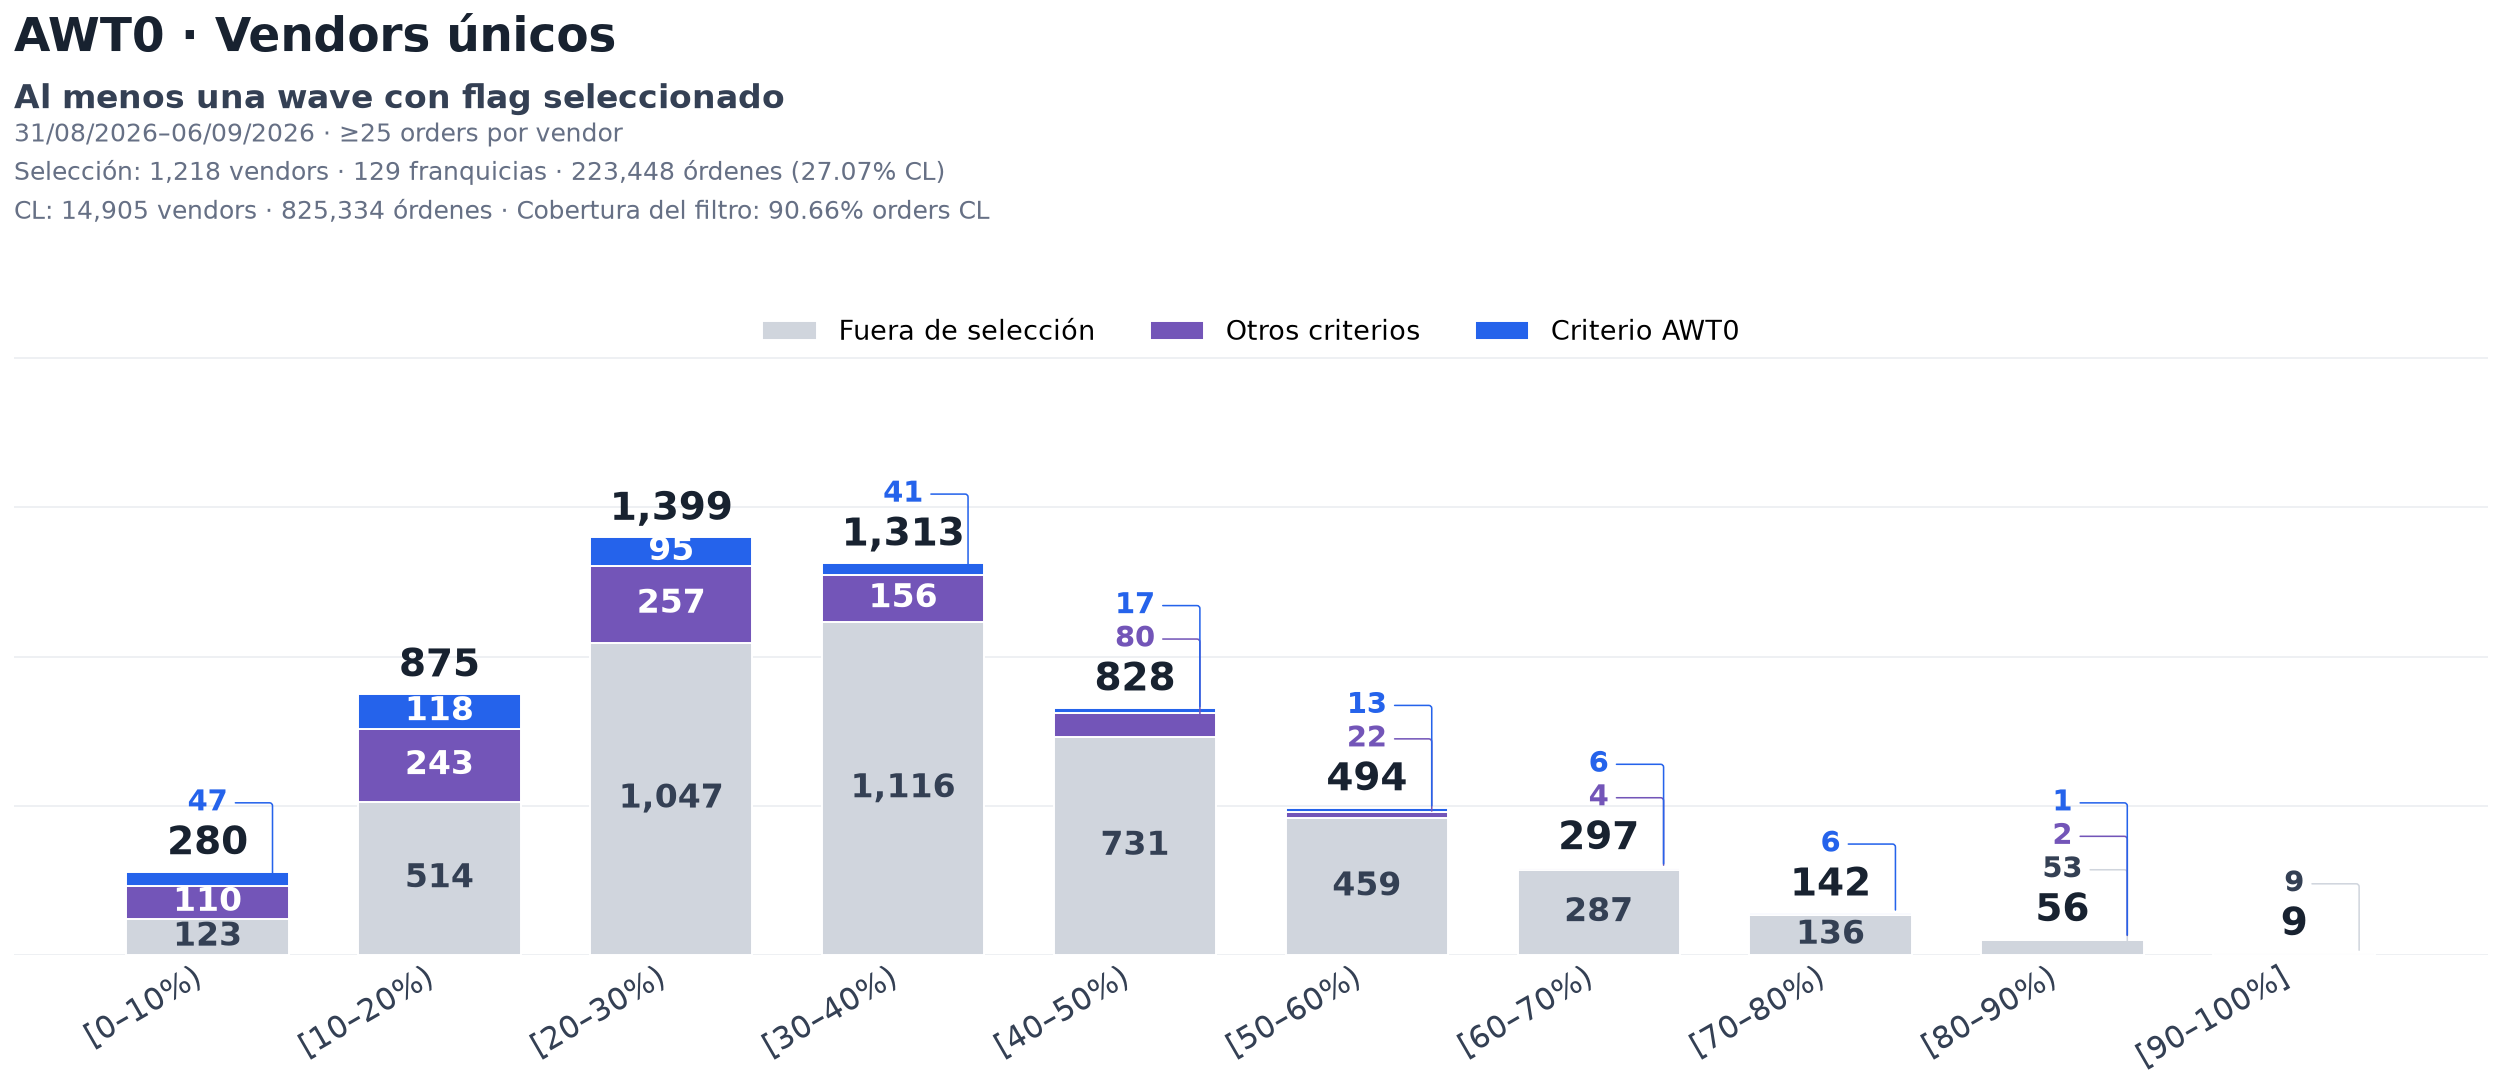

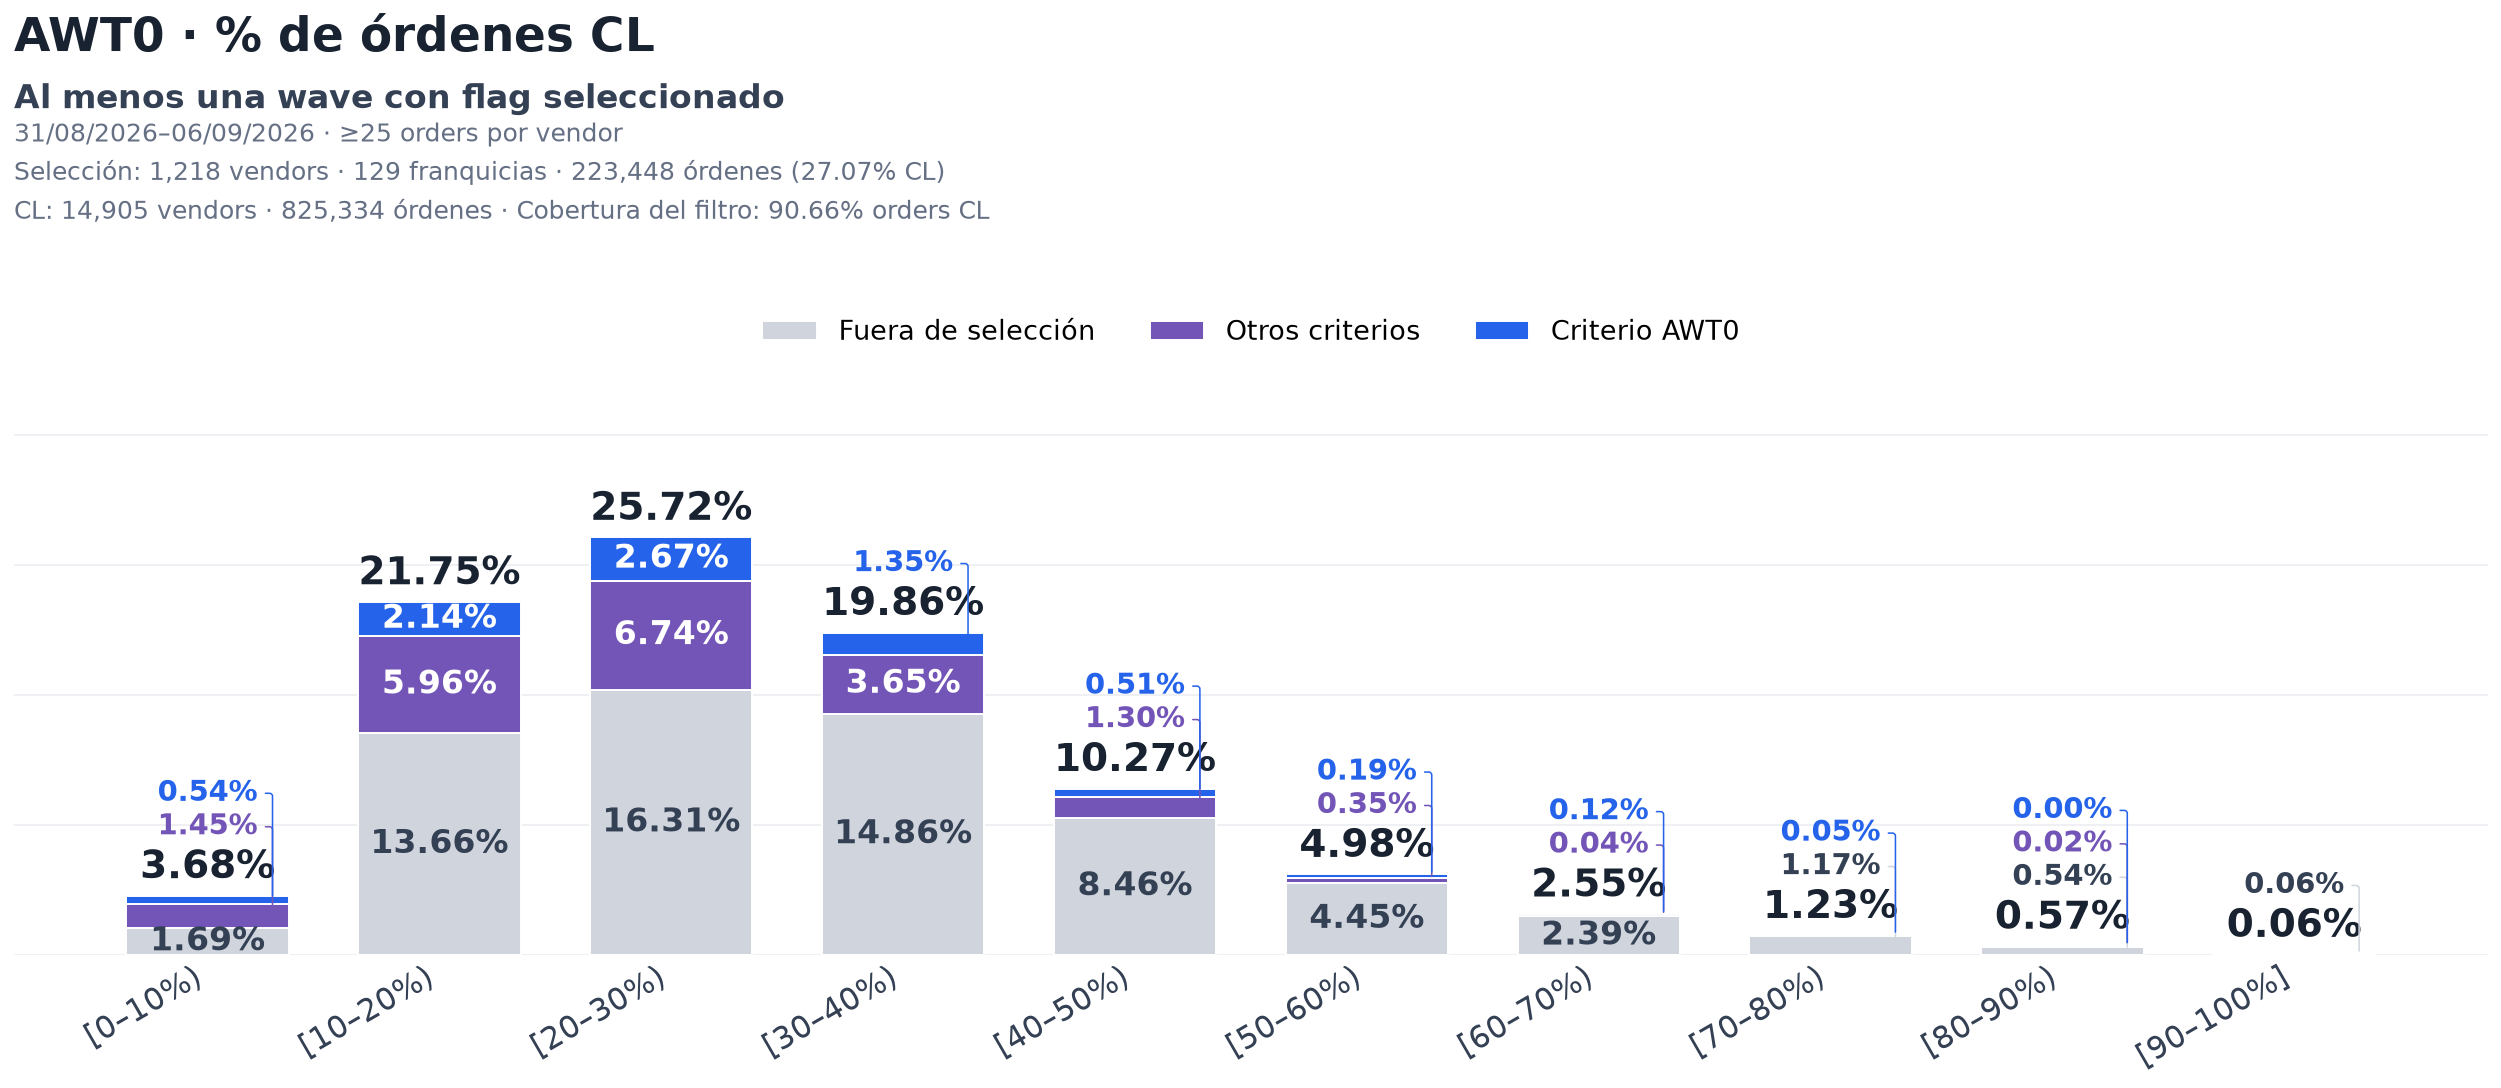

bucket,segment,vendors,total_orders,orders_share_cl_pct,ept_avg,seamless_pct,seamless_coverage_pct
[0–10%),Criterio AWT0,47,"4,430",0.54%,7.43,83.75%,100.00%
[0–10%),Fuera de selección,123,"13,909",1.69%,8.69,78.79%,100.00%
[0–10%),Otros criterios,110,"11,997",1.45%,12.58,74.17%,100.00%
[10–20%),Criterio AWT0,118,"17,630",2.14%,10.64,84.08%,100.00%
[10–20%),Fuera de selección,514,"112,717",13.66%,10.21,83.82%,100.00%
[10–20%),Otros criterios,243,"49,189",5.96%,14.71,78.69%,100.00%
[20–30%),Criterio AWT0,95,"22,041",2.67%,13.29,85.66%,100.00%
[20–30%),Fuera de selección,"1,047","134,614",16.31%,12.84,84.32%,98.85%
[20–30%),Otros criterios,257,"55,590",6.74%,17.18,79.52%,100.00%
[30–40%),Criterio AWT0,41,"11,169",1.35%,17.17,85.06%,99.99%


Bucket,Vendors ≥25 orders,Vendors seleccionados,% vendors del bucket alcanzados,Orders del bucket,% orders CL del bucket,Orders seleccionadas,% orders CL alcanzadas,% orders del bucket alcanzadas,Seamless (%),Clasificación seamless (%),EPT promedio (min),AWT promedio (min),AWT0 real (%),AWTnull real (%)
[0–10%),280,83,29.64%,"30,336",3.68%,"8,801",1.07%,29.01%,77.69%,100.00%,10.04,6.39,6.81%,17.51%
[10–20%),875,154,17.60%,"179,536",21.75%,"27,627",3.35%,15.39%,82.44%,100.00%,11.48,4.85,15.36%,11.02%
[20–30%),"1,399",111,7.93%,"212,245",25.72%,"28,474",3.45%,13.42%,83.19%,99.27%,14.02,3.88,24.96%,11.01%
[30–40%),"1,313",44,3.35%,"163,932",19.86%,"13,135",1.59%,8.01%,85.48%,99.98%,14.92,2.99,34.68%,9.71%
[40–50%),828,20,2.42%,"84,739",10.27%,"4,935",0.60%,5.82%,85.91%,99.75%,14.37,2.23,44.50%,9.52%
[50–60%),494,13,2.63%,"41,120",4.98%,"1,575",0.19%,3.83%,85.44%,99.91%,13.04,1.54,53.99%,9.54%
[60–70%),297,4,1.35%,"21,031",2.55%,901,0.11%,4.28%,86.42%,99.64%,13.03,1.02,64.65%,8.14%
[70–80%),142,3,2.11%,"10,130",1.23%,370,0.04%,3.65%,90.42%,100.00%,9.67,0.54,73.72%,6.23%
[80–90%),56,0,0.00%,"4,666",0.57%,0,0.00%,0.00%,91.32%,100.00%,12.26,0.38,83.75%,3.66%
[90–100%],9,0,0.00%,531,0.06%,0,0.00%,0.00%,95.48%,100.00%,11.83,0.21,92.28%,0.94%


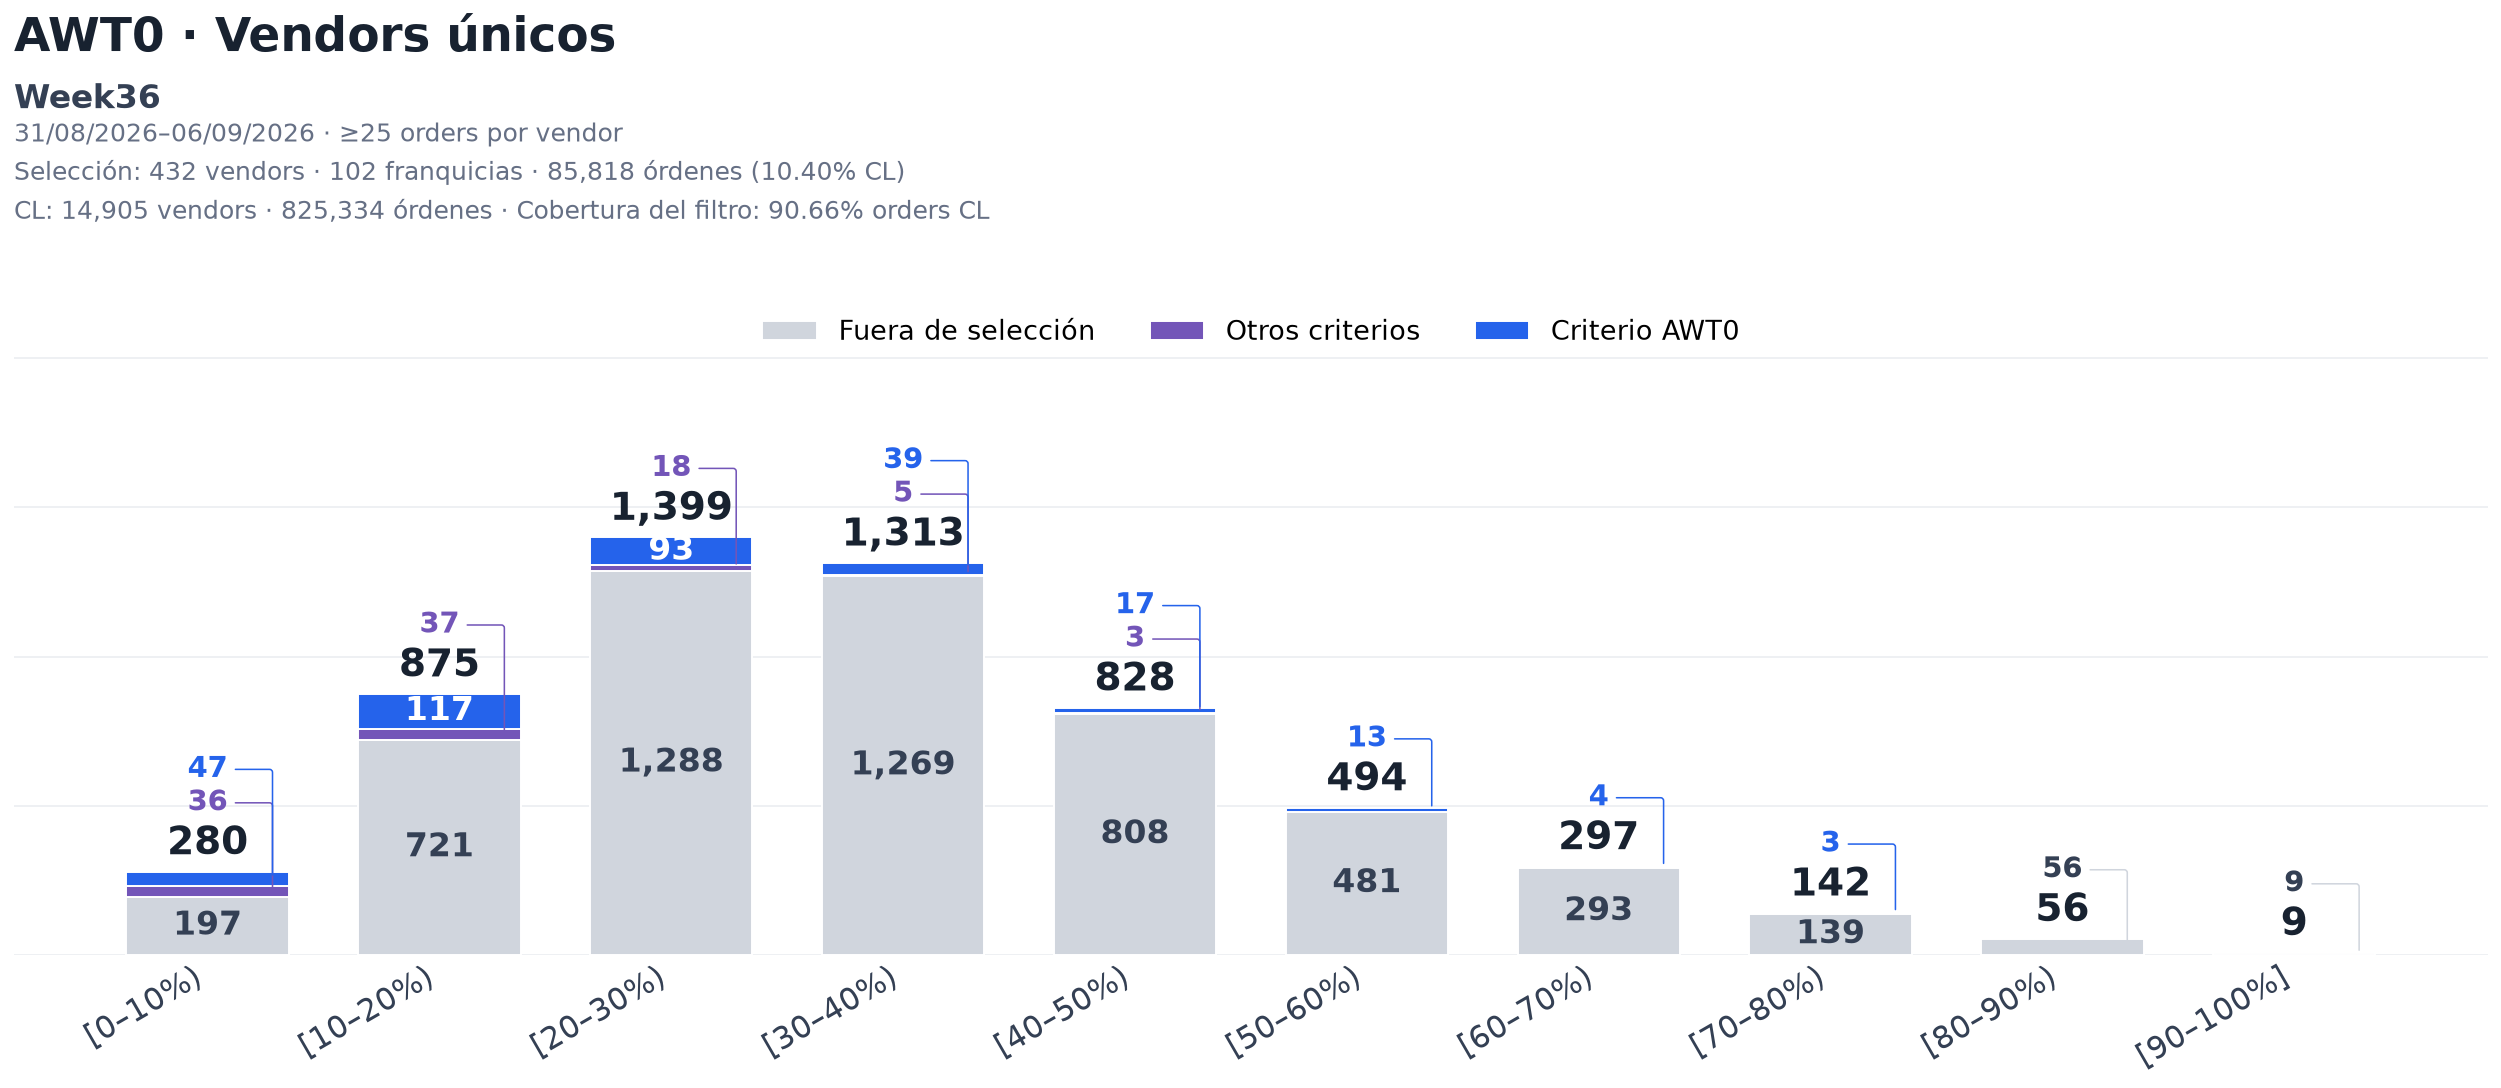

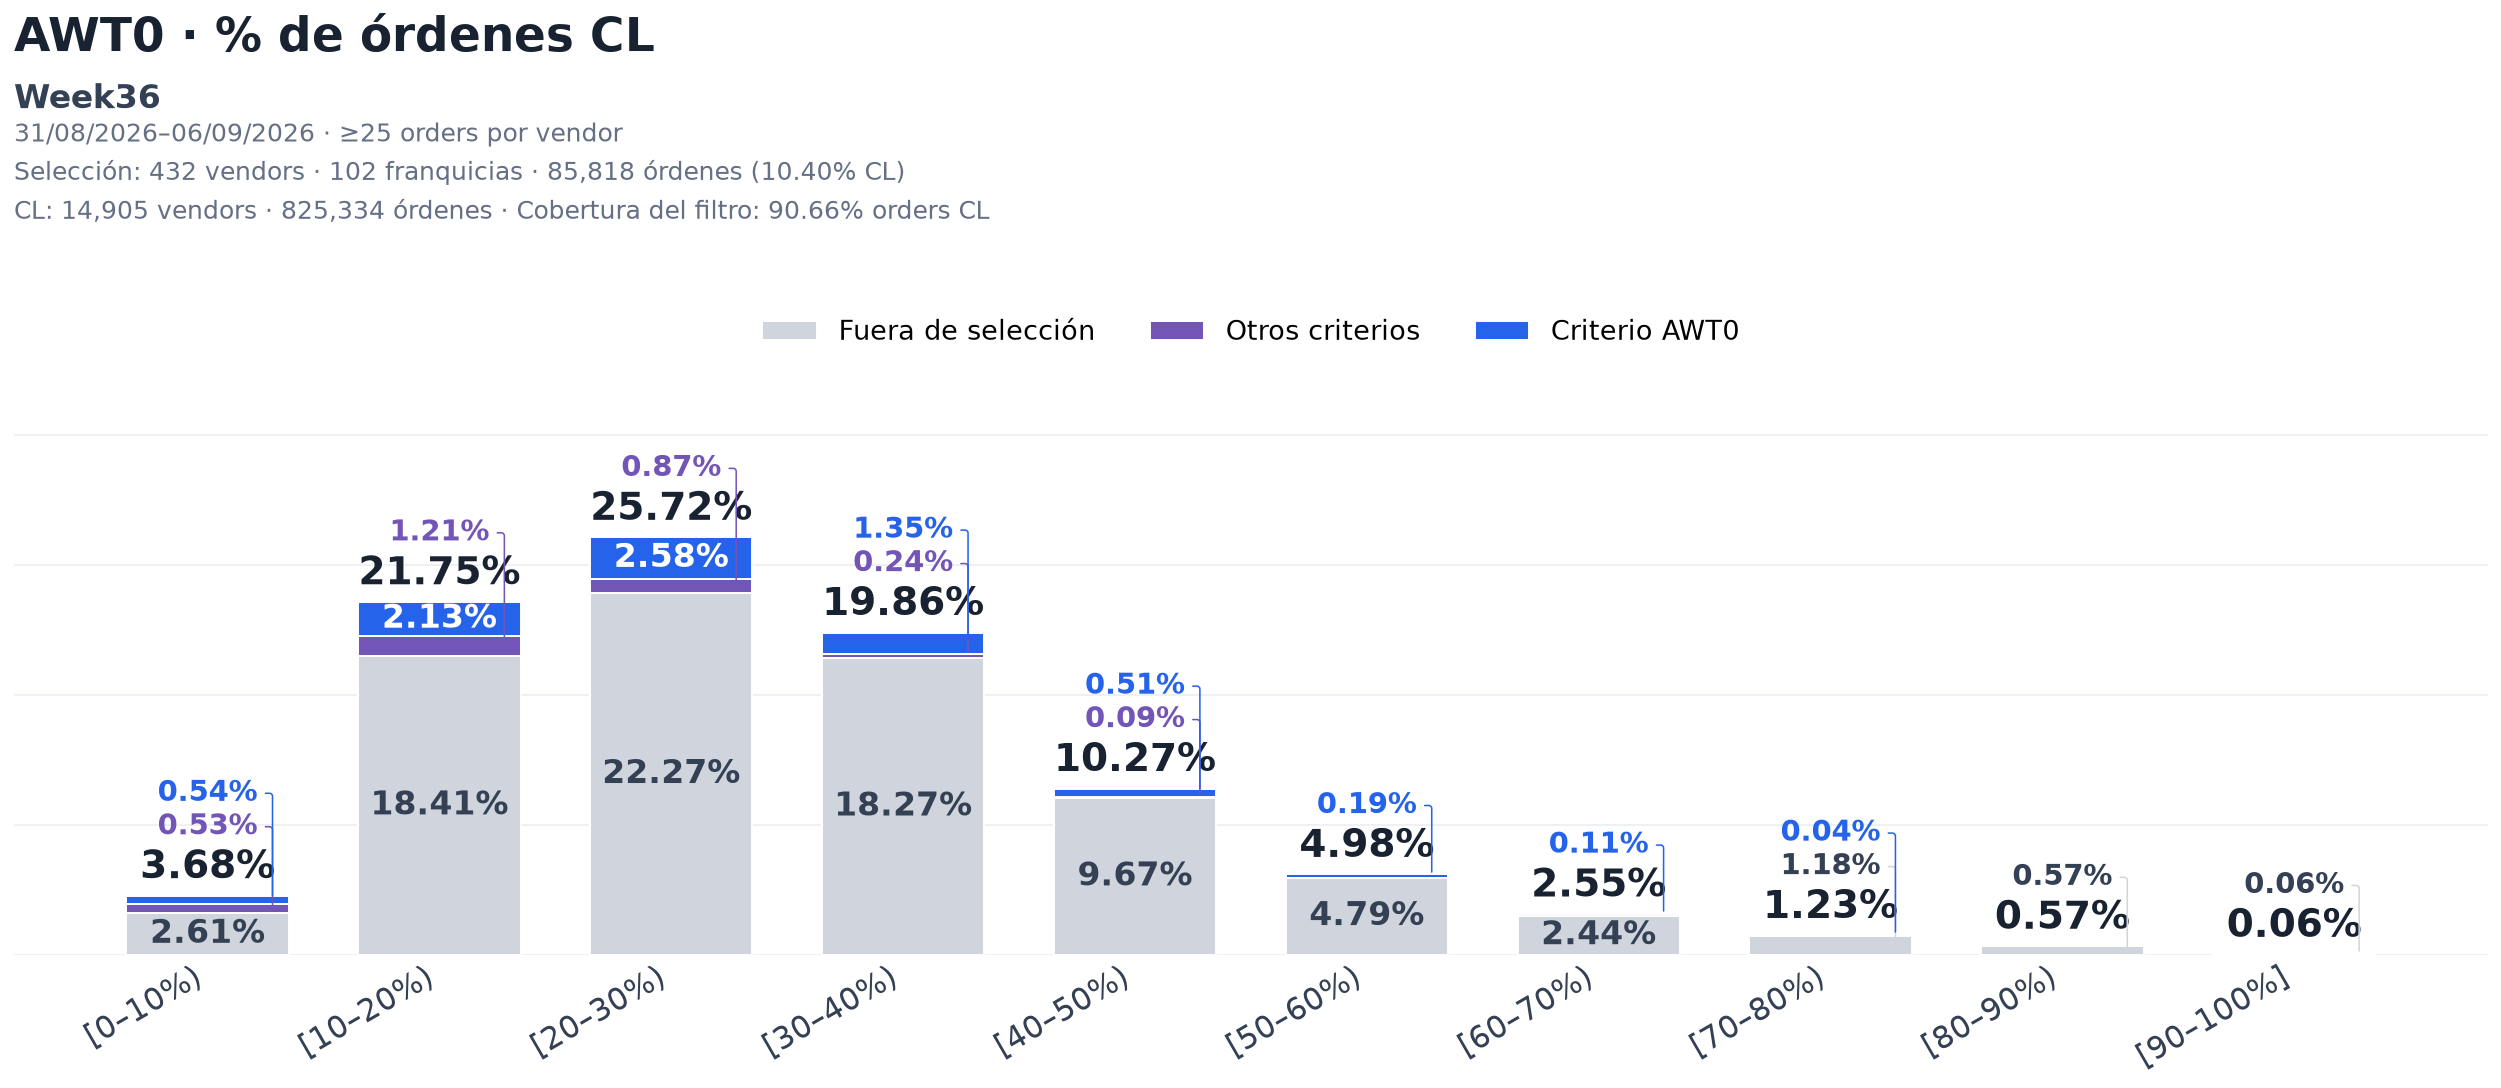

bucket,segment,vendors,total_orders,orders_share_cl_pct,ept_avg,seamless_pct,seamless_coverage_pct
[0–10%),Criterio AWT0,47,"4,430",0.54%,7.43,83.75%,100.00%
[0–10%),Fuera de selección,197,"21,535",2.61%,9.81,78.12%,100.00%
[0–10%),Otros criterios,36,"4,371",0.53%,13.82,69.41%,100.00%
[10–20%),Criterio AWT0,117,"17,603",2.13%,10.63,84.11%,100.00%
[10–20%),Fuera de selección,721,"151,909",18.41%,11.29,82.68%,100.00%
[10–20%),Otros criterios,37,"10,024",1.21%,15.91,75.98%,100.00%
[20–30%),Criterio AWT0,93,"21,314",2.58%,12.97,86.06%,100.00%
[20–30%),Fuera de selección,"1,288","183,771",22.27%,13.99,83.20%,99.16%
[20–30%),Otros criterios,18,"7,160",0.87%,17.94,74.50%,100.00%
[30–40%),Criterio AWT0,39,"11,116",1.35%,17.18,85.02%,99.99%


Bucket,Vendors ≥25 orders,Vendors seleccionados,% vendors del bucket alcanzados,Orders del bucket,% orders CL del bucket,Orders seleccionadas,% orders CL alcanzadas,% orders del bucket alcanzadas,Seamless (%),Clasificación seamless (%),EPT promedio (min),AWT promedio (min),AWT0 real (%),AWTnull real (%)
[0–10%),"2,520",468,18.57%,"420,196",50.91%,"109,676",13.29%,26.10%,87.02%,99.97%,12.58,3.28,32.08%,6.14%
[10–20%),"2,278",506,22.21%,"264,862",32.09%,"90,865",11.01%,34.31%,81.36%,99.95%,14.32,3.83,28.42%,13.77%
[20–30%),674,174,25.82%,"50,525",6.12%,"18,611",2.25%,36.84%,76.50%,96.90%,13.82,4.17,24.15%,23.70%
[30–40%),171,52,30.41%,"9,862",1.19%,"3,649",0.44%,37.00%,70.56%,99.49%,15.31,4.15,21.81%,33.66%
[40–50%),37,13,35.14%,"2,319",0.28%,481,0.06%,20.74%,51.75%,100.00%,18.69,5.42,16.30%,43.64%
[50–60%),8,4,50.00%,299,0.04%,135,0.02%,45.15%,61.20%,100.00%,14.34,10.06,7.36%,53.51%
[60–70%),3,0,0.00%,138,0.02%,0,0.00%,0.00%,48.55%,100.00%,14.98,4.03,7.25%,63.77%
[70–80%),2,1,50.00%,65,0.01%,31,0.00%,47.69%,35.38%,100.00%,10.92,3.02,7.69%,75.38%
[80–90%),0,0,—,0,0.00%,0,0.00%,—,—,—,—,—,—,—
[90–100%],0,0,—,0,0.00%,0,0.00%,—,—,—,—,—,—,—


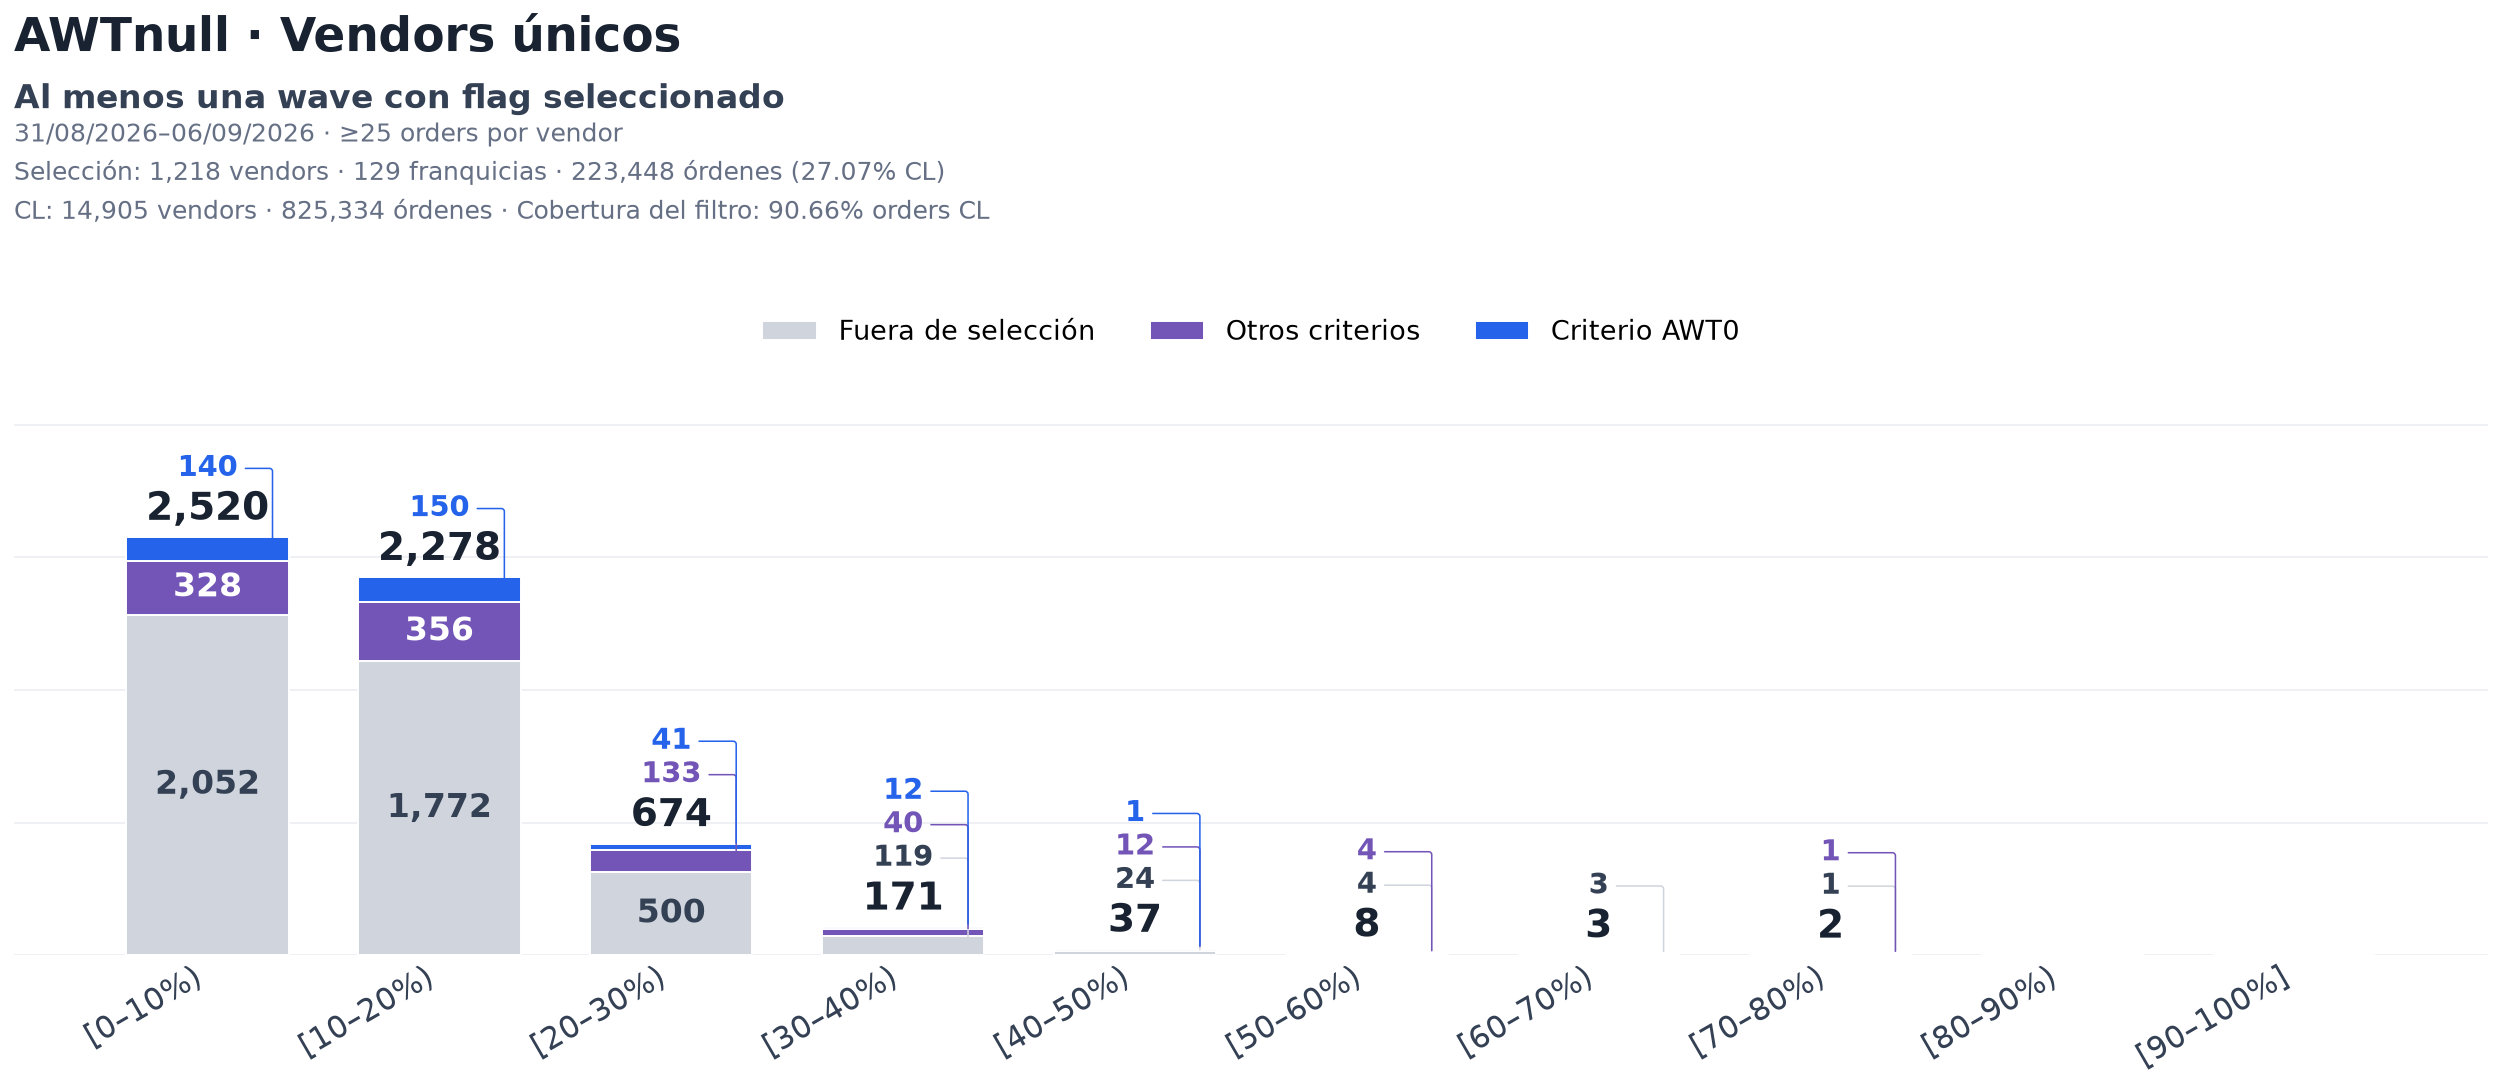

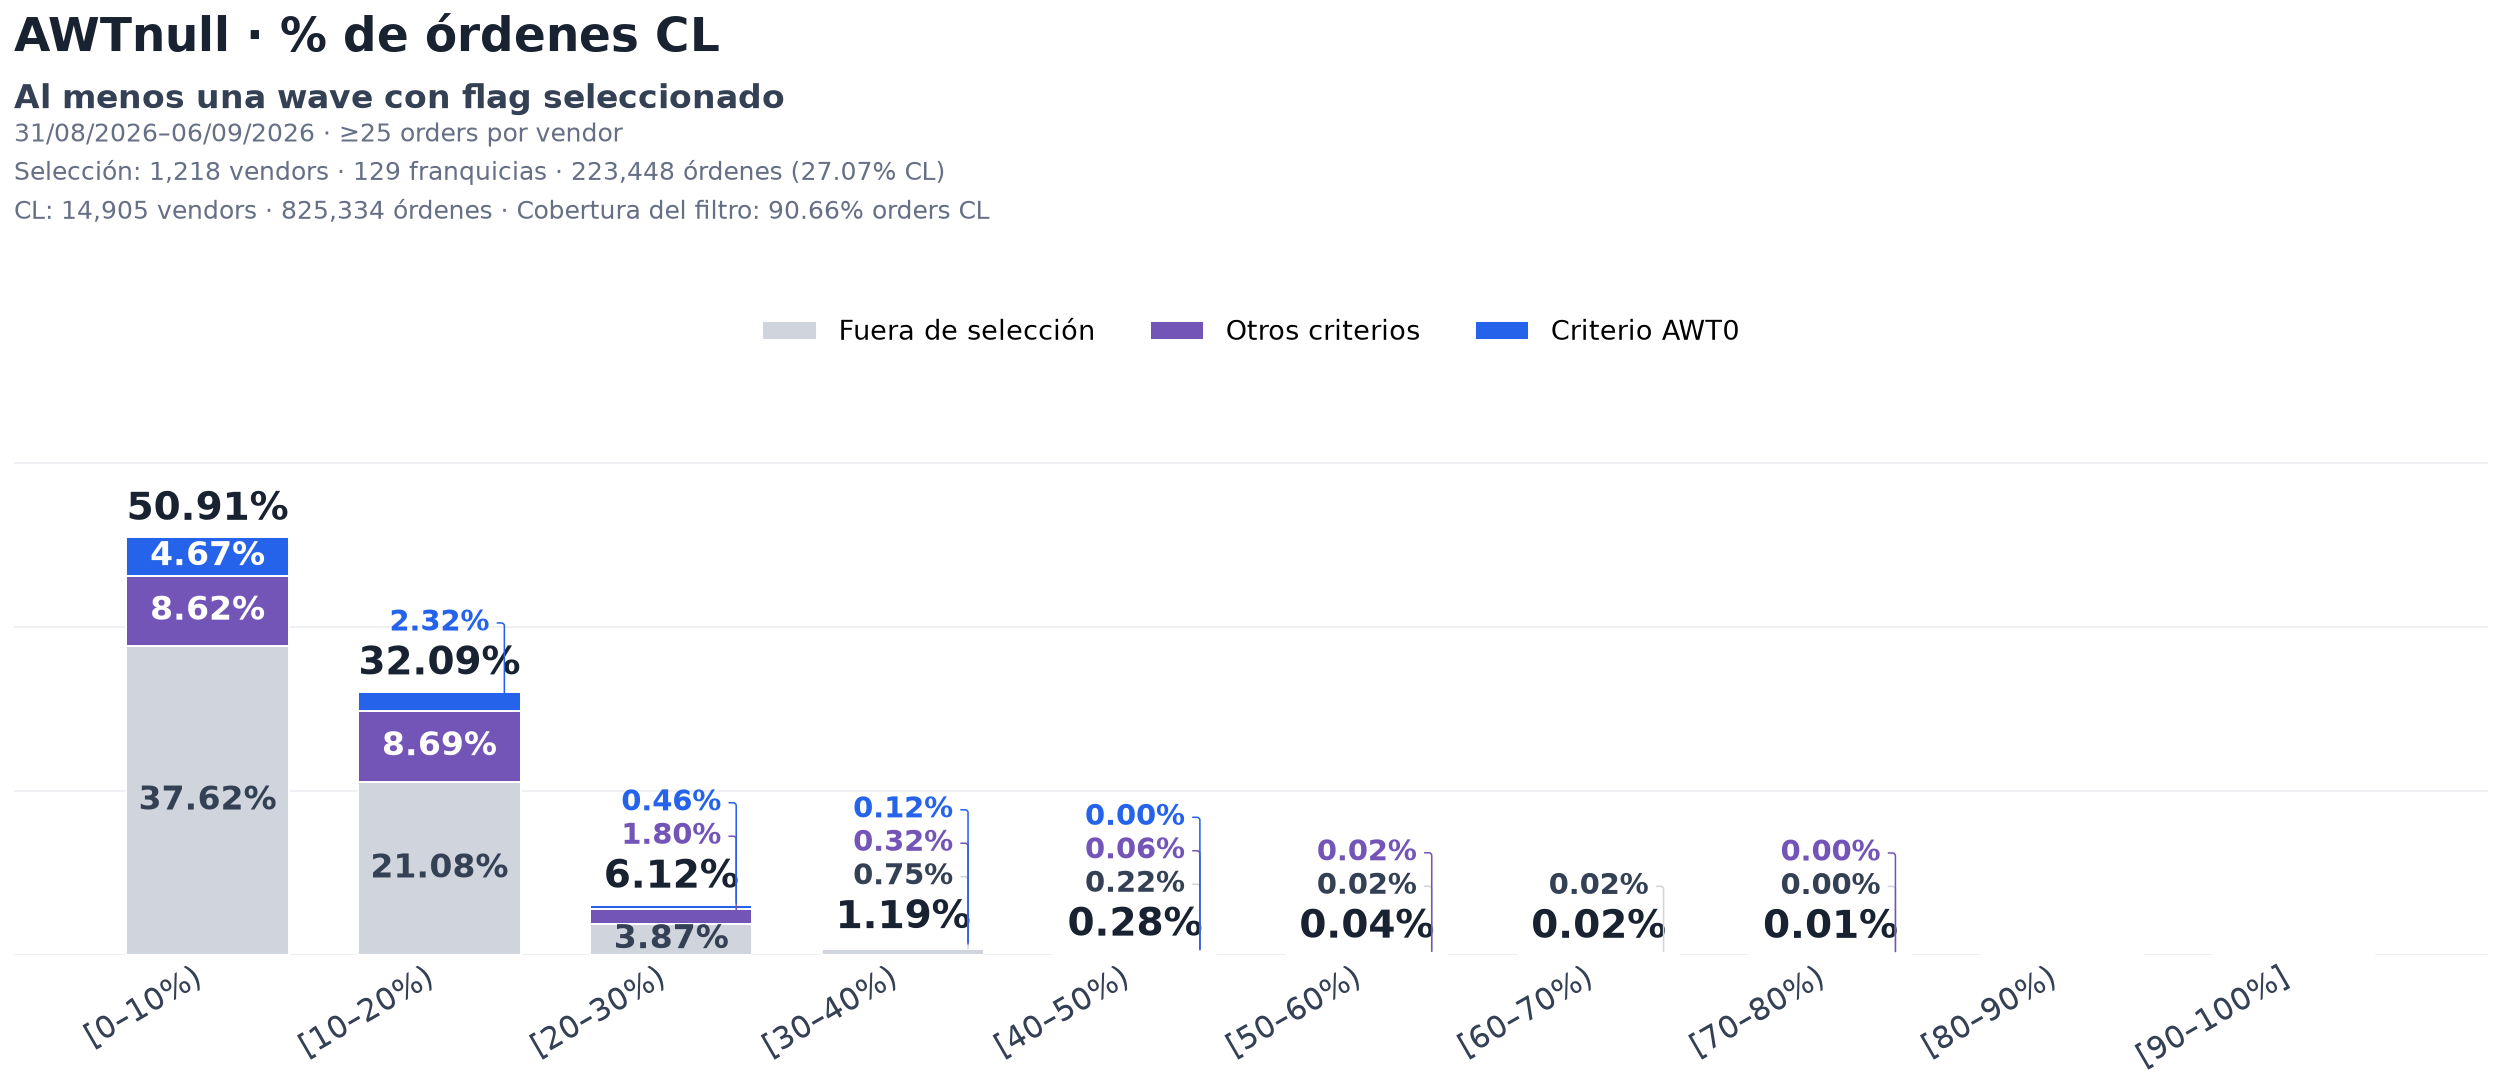

bucket,segment,vendors,total_orders,orders_share_cl_pct,ept_avg,seamless_pct,seamless_coverage_pct
[0–10%),Criterio AWT0,140,"38,564",4.67%,14.41,86.28%,100.00%
[0–10%),Fuera de selección,"2,052","310,520",37.62%,11.51,87.80%,99.95%
[0–10%),Otros criterios,328,"71,112",8.62%,16.27,84.00%,100.00%
[10–20%),Criterio AWT0,150,"19,120",2.32%,11.00,83.77%,99.99%
[10–20%),Fuera de selección,"1,772","173,997",21.08%,13.82,82.71%,99.92%
[10–20%),Otros criterios,356,"71,745",8.69%,16.40,77.44%,100.00%
[20–30%),Criterio AWT0,41,"3,791",0.46%,9.32,79.50%,100.00%
[20–30%),Fuera de selección,500,"31,914",3.87%,14.07,77.67%,95.10%
[20–30%),Otros criterios,133,"14,820",1.80%,14.43,73.34%,100.00%
[30–40%),Criterio AWT0,12,"1,009",0.12%,7.83,78.39%,100.00%


Bucket,Vendors ≥25 orders,Vendors seleccionados,% vendors del bucket alcanzados,Orders del bucket,% orders CL del bucket,Orders seleccionadas,% orders CL alcanzadas,% orders del bucket alcanzadas,Seamless (%),Clasificación seamless (%),EPT promedio (min),AWT promedio (min),AWT0 real (%),AWTnull real (%)
[0–10%),"2,520",159,6.31%,"420,196",50.91%,"46,310",5.61%,11.02%,87.02%,99.97%,12.58,3.28,32.08%,6.14%
[10–20%),"2,278",187,8.21%,"264,862",32.09%,"30,072",3.64%,11.35%,81.36%,99.95%,14.32,3.83,28.42%,13.77%
[20–30%),674,61,9.05%,"50,525",6.12%,"7,655",0.93%,15.15%,76.50%,96.90%,13.82,4.17,24.15%,23.70%
[30–40%),171,20,11.70%,"9,862",1.19%,"1,579",0.19%,16.01%,70.56%,99.49%,15.31,4.15,21.81%,33.66%
[40–50%),37,4,10.81%,"2,319",0.28%,171,0.02%,7.37%,51.75%,100.00%,18.69,5.42,16.30%,43.64%
[50–60%),8,0,0.00%,299,0.04%,0,0.00%,0.00%,61.20%,100.00%,14.34,10.06,7.36%,53.51%
[60–70%),3,0,0.00%,138,0.02%,0,0.00%,0.00%,48.55%,100.00%,14.98,4.03,7.25%,63.77%
[70–80%),2,1,50.00%,65,0.01%,31,0.00%,47.69%,35.38%,100.00%,10.92,3.02,7.69%,75.38%
[80–90%),0,0,—,0,0.00%,0,0.00%,—,—,—,—,—,—,—
[90–100%],0,0,—,0,0.00%,0,0.00%,—,—,—,—,—,—,—


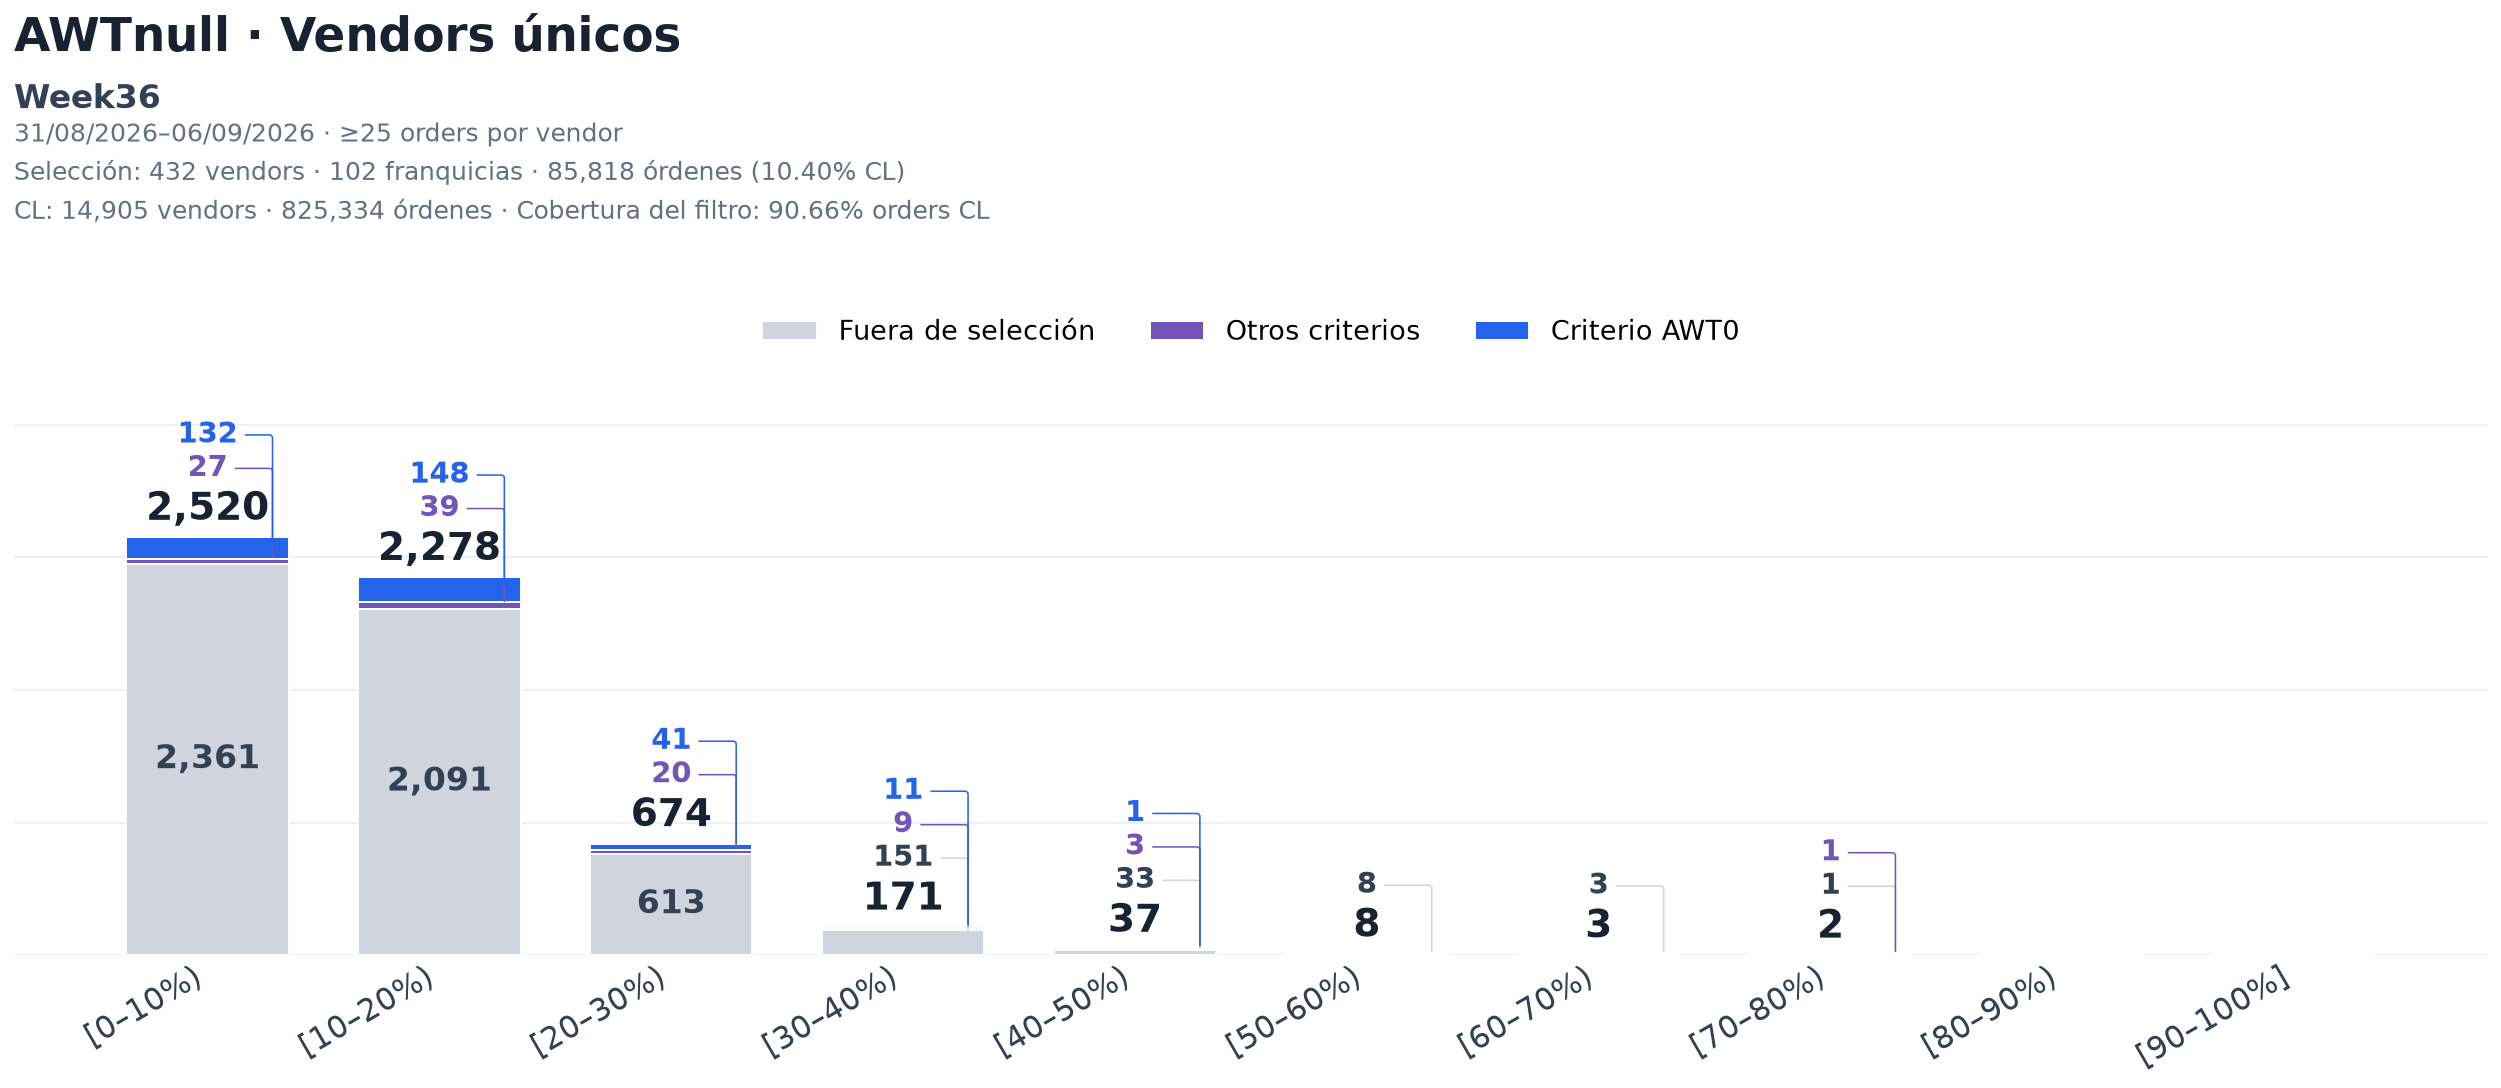

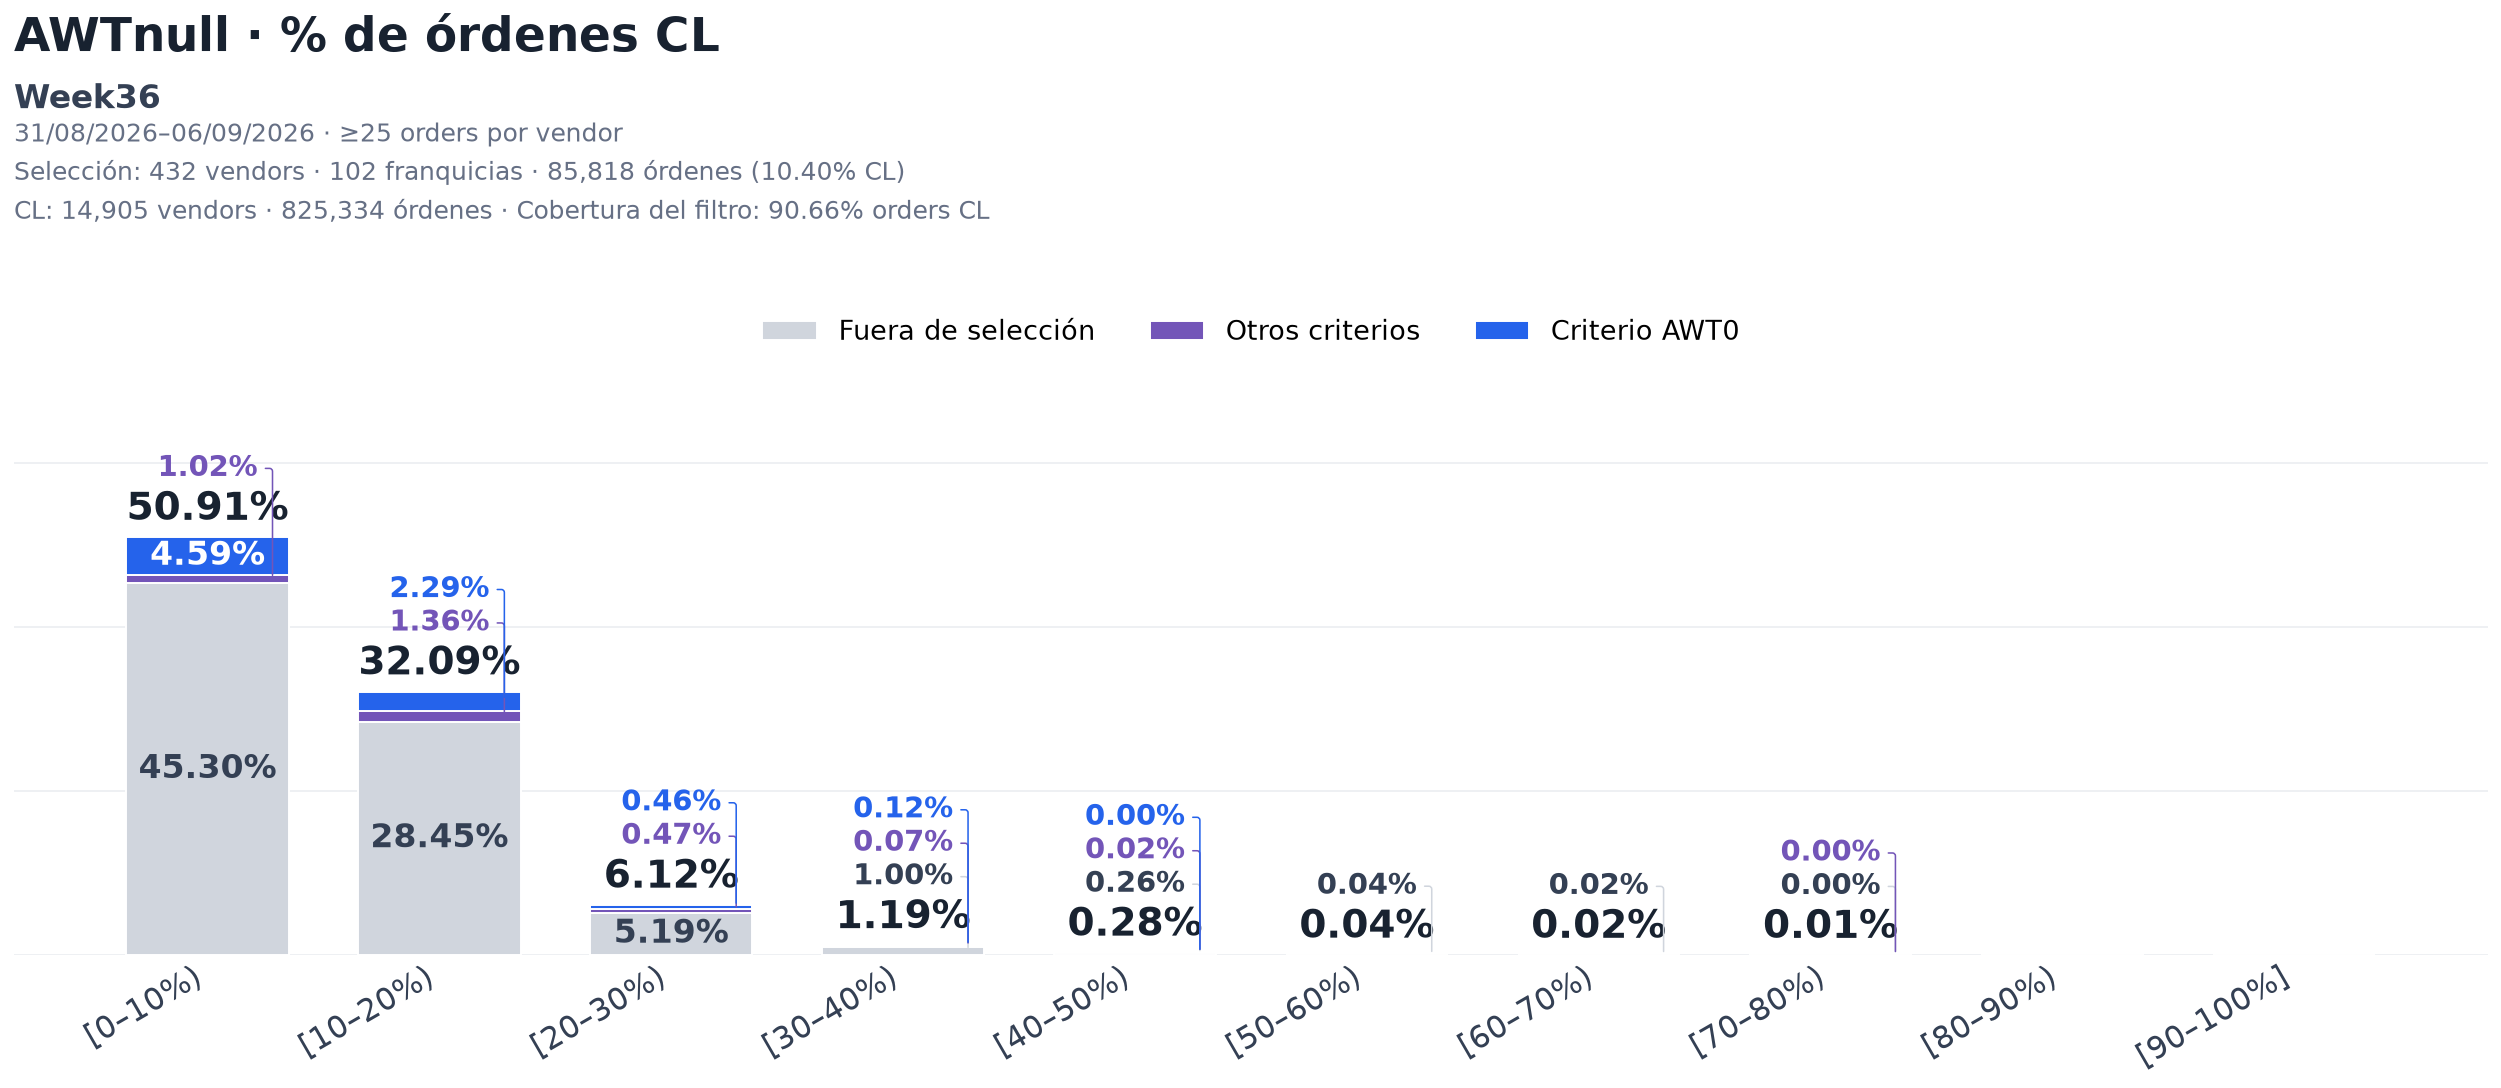

bucket,segment,vendors,total_orders,orders_share_cl_pct,ept_avg,seamless_pct,seamless_coverage_pct
[0–10%),Criterio AWT0,132,"37,877",4.59%,14.31,86.27%,100.00%
[0–10%),Fuera de selección,"2,361","373,886",45.30%,12.31,87.22%,99.96%
[0–10%),Otros criterios,27,"8,433",1.02%,16.67,81.35%,100.00%
[10–20%),Criterio AWT0,148,"18,860",2.29%,10.82,84.19%,99.99%
[10–20%),Fuera de selección,"2,091","234,790",28.45%,14.45,81.53%,99.94%
[10–20%),Otros criterios,39,"11,212",1.36%,17.37,72.90%,100.00%
[20–30%),Criterio AWT0,41,"3,791",0.46%,9.32,79.50%,100.00%
[20–30%),Fuera de selección,613,"42,870",5.19%,14.12,77.29%,96.35%
[20–30%),Otros criterios,20,"3,864",0.47%,14.88,65.17%,100.00%
[30–40%),Criterio AWT0,11,982,0.12%,7.50,78.72%,100.00%


Los vendors y sus órdenes se cuentan una vez en la vista de todas las waves, aunque sean reincidentes. Las vistas por wave se superponen y no deben sumarse.
Seamless (%) usa órdenes clasificadas. Clasificación seamless (%) indica su cobertura. EPT promedio se pondera por órdenes con EPT válido.


In [15]:
# RESULTADOS FINALES AWT0 / AWTnull — una misma semana y un mismo universo.
# Todos los cálculos ya se prepararon al inicio; aquí no se consultan otros Sheets.
MOSTRAR_ULTIMA_WAVE = True
MOSTRAR_CADA_WAVE = False  # Activa para visualizar todas las waves individualmente.
# Las tablas por wave se calculan siempre: awt_bucket_results_by_wave[(métrica, wave)].

for metric_label, _ in metrics_for_shares:
    selected_results = [awt_bucket_results[(metric_label, 'todas')]]
    if MOSTRAR_CADA_WAVE:
        selected_results += [awt_bucket_results_by_wave[(metric_label, wave)] for wave in wave_order_history]
    elif MOSTRAR_ULTIMA_WAVE and (metric_label, 'ultima') in awt_bucket_results:
        selected_results.append(awt_bucket_results[(metric_label, 'ultima')])
    for result in selected_results:
        # The show_awt_bucket_table function calls presentation_table internally,
        # so its colors cannot be directly changed from this cell.
        show_awt_bucket_table(result, f'{metric_label} · {result["selection_label"]}')
        plot_awt_bucket_stack(result, metric_label, mode='vendors')
        plot_awt_bucket_stack(result, metric_label, mode='orders')
        # Tabla de métricas por segmento: permite comparar seleccionados y resto.
        detail_cols = ['bucket', 'segment', 'vendors', 'total_orders', 'orders_share_cl_pct',
                       'ept_avg', 'seamless_pct', 'seamless_coverage_pct']

        # Reverted to a direct call to presentation_table without additional styling.
        display(presentation_table(result['detail'][detail_cols],
            f'{metric_label}: EPT y seamless por segmento',
            {'vendors': '{:,.0f}', 'total_orders': '{:,.0f}', 'orders_share_cl_pct': '{:.2f}%',
             'ept_avg': '{:.2f}', 'seamless_pct': '{:.2f}%', 'seamless_coverage_pct': '{:.2f}%'}))

print('Los vendors y sus órdenes se cuentan una vez en la vista de todas las waves, '
      'aunque sean reincidentes. Las vistas por wave se superponen y no deben sumarse.')
print('Seamless (%) usa órdenes clasificadas. Clasificación seamless (%) indica su cobertura. '
      'EPT promedio se pondera por órdenes con EPT válido.')